# Leyenda - Livrable 1 : Classification d'Images par Réseaux de Neurones

### Groupe 2 : Dhieddine SMAOUI, Anas EZZOUHOUR, Rayane ASAADI, Matisse APPÉRÉ, Aymen EL OUAGOUTI

---

## Présentation du Problème

L'entreprise Leyenda souhaite automatiser la sélection de photos pour l'annotation.
Ce livrable fournit un système de classification binaire et multi-classes
capable de filtrer automatiquement les images et de les trier dans `data/processed/`.

**Objectif final** : réduire le travail manuel d'annotation en éliminant automatiquement
toutes les images qui ne sont pas des photographies réelles (peintures, schémas, croquis, textes).

### Dataset - 5 catégories

| Catégorie | Description | Difficulté de classification |
|---|---|---|
| **Photo** | Photographies réelles - **classe cible** | Référence |
| **Painting** | Peintures - dont certaines hyper-réalistes | Elevée : texture proche d'une photo |
| **Schematics** | Schémas et diagrammes techniques | Faible : très différents visuellement |
| **Sketch** | Croquis et dessins en N&B | Faible : pas de couleur, traits simples |
| **Text** | Documents textuels scannés | Faible : structure très régulière |

### Stratégie globale du livrable

```
Données brutes (5 classes)
       |
       v
  Nettoyage & Outliers --> Données propres
       |
       v
  Split stratifié --> Train 64% / Val 16% / Test 20%
       |
       v
  CNN from scratch --> Entraînement avec régularisation
       |
       v
  Evaluation --> Métriques + Courbe ROC + Seuil optimal (Youden J)
       |
       v
  Tri automatique --> data/processed/Photo/  +  data/processed/Not_Photo/
```

### Livrables produits

| Fichier | Description |
|---|---|
| `cnn_scratch.keras` | Modèle sauvegardé - prêt pour déploiement |
| `metadata.json` | Fiche technique du modèle (hyperparamètres + métriques) |
| `classification_report.csv` | Prédiction de chaque image avec probabilité |
| `figures/` | Courbes d'entraînement, matrice de confusion, courbe ROC |

---
## 1. Imports & Configuration

### Bibliothèques

| Bibliothèque | Module / Fonction clé | Rôle dans ce projet |
|---|---|---|
| **TensorFlow 2.x** | `tf.keras`, `tf.data` | Framework Deep Learning : construction du CNN, pipeline de données, entraînement GPU |
| **Keras (API haute niveau)** | `Sequential`, `layers` | Définition de l'architecture couche par couche |
| **NumPy** | `np.array`, `np.mean` | Calcul numérique : métriques, manipulation des tenseurs en dehors de TF |
| **Pandas** | `pd.DataFrame` | Rapports CSV, tableaux de résultats formatés |
| **Matplotlib** | `plt.plot`, `plt.imshow` | Courbes d'entraînement, grilles d'images, diagrammes d'architecture |
| **Seaborn** | `sns.heatmap` | Matrice de confusion avec mise en forme automatique |
| **scikit-learn** | `train_test_split`, `roc_auc_score` | Split stratifié, métriques d'évaluation avancées |
| **pathlib.Path** | `Path.mkdir`, `Path.rglob` | Gestion cross-platform des chemins (évite les problèmes Windows/Linux) |

### Couches Keras

| Couche | Rôle |
|---|---|
| `Conv2D` | Extraction de features spatiales par convolution (noyau glissant) |
| `MaxPooling2D` | Réduction spatiale x2 - invariance aux petites translations |
| `BatchNormalization` | Normalise les activations -> entraînement plus stable et rapide |
| `Dropout` | Désactive aléatoirement des neurones -> régularisation contre l'overfitting |
| `GlobalAveragePooling2D` | Remplace Flatten - prend la moyenne spatiale -> moins de paramètres |
| `Dense` | Couche entièrement connectée - classifieur final |
| `RandomFlip/Rotation/Zoom/Contrast` | Augmentation de données en ligne pendant l'entraînement |

### Callbacks

| Callback | Paramètre principal | Comportement |
|---|---|---|
| `EarlyStopping` | `patience=10` | Arrête si `val_loss` ne descend plus pendant 10 époques |
| `ReduceLROnPlateau` | `factor=0.5, patience=5` | Divise le learning rate par 2 si `val_loss` stagne |
| `ModelCheckpoint` | `monitor='val_loss'` | Sauvegarde automatiquement le meilleur checkpoint |

### Random seed = 42

La même graine est fixée dans **NumPy**, **TensorFlow** et **Python `random`** pour garantir la
**reproductibilité complète** : le même code sur la même machine produit toujours les mêmes résultats.
Sans cela, les splits, les poids initiaux et l'augmentation varieraient à chaque exécution,
rendant la comparaison de configurations impossible.

In [1]:
# %pip install --upgrade tensorflow keras numpy pandas matplotlib scikit-learn seaborn -q dotenv

# --- Stabilite TensorFlow / CUDA ---
# A placer AVANT import tensorflow.
# False = utiliser le GPU ; True = forcer le CPU en cas de crash CUDA.
FORCE_TF_CPU = False

# --- Librairies de calcul et manipulation de données ---
import numpy as np          # Calcul numérique (tableaux, statistiques)
import pandas as pd         # Tableaux (DataFrames) pour les rapports et exports CSV
import os, random, shutil   # Opérations système, aléatoire, copie de fichiers
if FORCE_TF_CPU:
    os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
    os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import json                 # Lecture/écriture de fichiers JSON (métadonnées)
import warnings
from pathlib import Path    # Manipulation de chemins de fichiers (cross-platform)

# --- Visualisation ---
import matplotlib.pyplot as plt          # Graphiques et affichage d'images
import matplotlib.patches as mpatches   # Légendes personnalisées (patches colorés)
import seaborn as sns                    # Heatmaps (matrice de confusion)

# --- Deep Learning (TensorFlow / Keras) ---
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print(f"Impossible d'activer memory_growth sur {gpu}: {e}")

from tensorflow.keras import Sequential, layers
from tensorflow.keras.layers import (
    Conv2D,                  # Couche convolutive : détecte des motifs locaux (bords, textures)
    MaxPooling2D,            # Sous-échantillonnage : réduit la carte de features x 2
    Dense,                   # Couche entièrement connectée (classifieur final)
    Dropout,                 # Régularisation : désactive des neurones aléatoirement
    BatchNormalization,      # Normalise les activations -> entraînement plus stable
    GlobalAveragePooling2D,  # Remplace Flatten : prend la moyenne spatiale -> moins de params
    RandomFlip, RandomRotation, RandomZoom, RandomContrast  # Augmentation de données
)
from tensorflow.keras.callbacks import (
    EarlyStopping,      # Arrête l'entraînement si la métrique stagne
    ReduceLROnPlateau,  # Réduit le learning rate sur plateau
    ModelCheckpoint     # Sauvegarde automatique du meilleur modèle
)

# --- Métriques d'évaluation (scikit-learn) ---
from sklearn.metrics import (
    classification_report,  # Précision / rappel / F1 par classe
    confusion_matrix,        # Tableau TP / FP / TN / FN
    roc_auc_score,           # Aire sous la courbe ROC (mesure globale de discrimination)
    roc_curve                # Coordonnées (FPR, TPR) pour tracer la courbe ROC
)

warnings.filterwarnings('ignore')

# --- Graine aléatoire globale ---
# On fixe la même graine dans numpy, TensorFlow et Python random
# pour que les résultats soient reproductibles d'une exécution à l'autre.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print(f"TensorFlow  : {tf.__version__}")
print(f"GPU dispo   : {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1780265202.047437  304881 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow  : 2.21.0
GPU dispo   : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# -----------------------------------------------------------------
# CONFIGURATION CENTRALISEE
# Tous les chemins et hyperparamètres sont définis ici pour
# faciliter les modifications sans toucher au reste du code.
# -----------------------------------------------------------------

# --- Chemins du projet ---
# Le notebook reste portable : il peut être lancé depuis la racine du projet
# ou depuis le dossier notebooks/ sans dépendre d'un chemin Windows personnel.
NOTEBOOK_CWD = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_CWD.parent if NOTEBOOK_CWD.name == 'notebooks' else NOTEBOOK_CWD

DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
DATA_PROC = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'src' / 'models'
FIGURES_DIR = PROJECT_ROOT / 'notebooks' / 'figures'

EXPECTED_CLASSES = ['Photo', 'Painting', 'Schematics', 'Sketch', 'Text']
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

# Crée les dossiers de sortie s'ils n'existent pas encore
for d in [DATA_PROC / 'Photo', DATA_PROC / 'Not_Photo', MODELS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# --- Paramètres des images ---
IMAGE_H = 224
IMAGE_W = 224

# --- Paramètres d'entraînement ---
BATCH_SIZE = 32
EPOCHS_CNN = 20

# --- Seuil de décision ---
# Initialisé à 0.5, puis remplacé en section 7 par le seuil optimal
# choisi sur validation avec Youden J.
THRESHOLD = 0.5

print(' Chemins configurés :')
print(f'  project   : {PROJECT_ROOT}')
print(f'  raw       : {DATA_RAW}')
print(f'  processed : {DATA_PROC}')
print(f'  models    : {MODELS_DIR}')
print(f'  figures   : {FIGURES_DIR}')
print(f'\n Dimensions des images : {IMAGE_H}x{IMAGE_W}')
print(f' Taille des batches    : {BATCH_SIZE}')
print(f' Epochs max            : {EPOCHS_CNN}')

# Vérifie que le dossier de données brutes existe et liste les catégories
if DATA_RAW.exists():
    print(f'\n Répertoire trouvé : {DATA_RAW}')
    print('\n Catégories détectées :')
    for folder in sorted(DATA_RAW.iterdir()):
        if folder.is_dir():
            n = len([p for p in folder.rglob('*') if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS])
            print(f'  - {folder.name:<15} : {n} images')
else:
    raise FileNotFoundError(f'Dossier de données introuvable : {DATA_RAW}')

 Chemins configurés :
  project   : /home/aymen/DS/Leyenda
  raw       : /home/aymen/DS/Leyenda/data/raw
  processed : /home/aymen/DS/Leyenda/data/processed
  models    : /home/aymen/DS/Leyenda/src/models
  figures   : /home/aymen/DS/Leyenda/notebooks/figures

 Dimensions des images : 224x224
 Taille des batches    : 32
 Epochs max            : 20

 Répertoire trouvé : /home/aymen/DS/Leyenda/data/raw

 Catégories détectées :
  - Painting        : 1405 images
  - Photo           : 5624 images
  - Schematics      : 1406 images
  - Sketch          : 1406 images
  - Text            : 1406 images


---
## 2. Vérification & Nettoyage des données

### Pourquoi cette étape est indispensable

Les datasets téléchargés depuis des sources variées contiennent souvent des images corrompues.
Laisser ces fichiers dans le dataset provoque :
- Des **erreurs d'exécution** pendant le chargement (crash du notebook)
- Des **statistiques faussées** sur le nombre d'images par classe
- Des **biais silencieux** si les images corrompues appartiennent à une classe spécifique

### Types de corruption détectés

| Type | Cause probable | Conséquence si non nettoyé |
|---|---|---|
| Fichier tronqué | Téléchargement interrompu | `InvalidArgumentError` au décodage |
| Format non supporté | Fichier TIFF, RAW, HEIC | Exception TensorFlow non catchée |
| Image 1 ou 2 canaux | Niveaux de gris ou transparence | Erreur de shape lors du batching |
| Fichier vide | Extraction ZIP incomplète | Division par zéro dans les statistiques |

### Méthode - Décodage test avec TensorFlow

```python
tf.io.decode_image(tf.io.read_file(path), channels=3)
```

On utilise **le même pipeline TF** que lors de l'entraînement :
une image qui passe ce test passera également l'entraînement.
Les images qui échouent sont **supprimées immédiatement** du disque.

> **Note sur le parcours récursif** : les archives ZIP imbriquées créent souvent des sous-dossiers
> (ex. `Photo/photos_batch1/img001.jpg`). Le parcours récursif avec `.rglob('*')` garantit
> que toutes les images sont vérifiées, quelle que soit la profondeur de l'arborescence.

In [3]:
def verify_and_clean_images(data_path):
    """Vérifie l'intégrité de toutes les images et supprime les corrompues."""
    stats = {'total': 0, 'valid': 0, 'corrupted': 0, 'by_class': {}}

    # Extensions acceptées
    EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

    print(" Vérification de l'intégrité des images...\n")

    # IMPORTANT: parcours récursif dans chaque classe
    # (dans ton cas, les zips extraits créent souvent des sous-dossiers)
    for subfolder in sorted(data_path.iterdir()):
        if not subfolder.is_dir():
            continue

        class_stats = {'valid': 0, 'corrupted': 0}

        images = [
            p for p in sorted(subfolder.rglob('*'))
            if p.is_file() and p.suffix.lower() in EXTENSIONS
        ]

        if not images:
            print(f"   {subfolder.name:<15}: 0 image trouvée (structure potentiellement imbriquée ou extraction incomplète)")
            stats['by_class'][subfolder.name] = class_stats
            continue

        for img_path in images:
            stats['total'] += 1
            try:
                img_bytes = tf.io.read_file(str(img_path))
                tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
                stats['valid'] += 1
                class_stats['valid'] += 1
            except Exception as e:
                stats['corrupted'] += 1
                class_stats['corrupted'] += 1
                print(f"   Corrompue : {img_path.name}  ({e})")
                try:
                    img_path.unlink()
                except Exception:
                    pass

        stats['by_class'][subfolder.name] = class_stats
        print(f"  {subfolder.name:<15}: {class_stats['valid']} valides, "
              f"{class_stats['corrupted']} corrompues")

    print(f"\n Total : {stats['valid']}/{stats['total']} images valides "
          f"({stats['corrupted']} supprimées)")
    return stats


# --- Appel de la fonction de vérification ---
if not DATA_RAW.exists():
    print(f"  {DATA_RAW} introuvable - placez vos images dans des sous-dossiers.")
    DATA_RAW.mkdir(parents=True, exist_ok=True)
    image_stats = {'total': 0, 'valid': 0, 'corrupted': 0, 'by_class': {}}
else:
    image_stats = verify_and_clean_images(DATA_RAW)

 Vérification de l'intégrité des images...



I0000 00:00:1780265208.132097  304881 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1763 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


  Painting       : 1405 valides, 0 corrompues
  Photo          : 5624 valides, 0 corrompues
  Schematics     : 1406 valides, 0 corrompues
  Sketch         : 1406 valides, 0 corrompues
  Text           : 1406 valides, 0 corrompues

 Total : 11247/11247 images valides (0 supprimées)


---
## 3. Chargement & Exploration des données

### Stratégie de split - 64 % / 16 % / 20 %

| Jeu | Proportion | Rôle | Propriété importante |
|---|---|---|---|
| **Train** | 64 % | Mise à jour des poids (rétropropagation) | Shufflé à chaque époque |
| **Validation** | 16 % | Pilote EarlyStopping, ReduceLROnPlateau, choix du seuil | Jamais shufflé - résultats stables |
| **Test** | 20 % | Evaluation finale honnête | Jamais vu pendant l'entraînement **ni** le tuning |

Le split est réalisé en **deux étapes stratifiées** :
1. `train_test_split(all, test_size=0.20)` -> isole 20% pour le test
2. `train_test_split(train, test_size=0.20)` -> tire 20% des 80% restants pour la val (= 16% global)

En proportions globales :

$$
p_{train}=0.8 \times 0.8=0.64, \qquad
p_{val}=0.8 \times 0.2=0.16, \qquad
p_{test}=0.20
$$

La **stratification** garantit que la proportion de chaque classe dans chaque jeu est identique
au dataset original. Sans elle, la classe minoritaire (Photo) pourrait être absente du test set.

### Détection des outliers avant le split

Filtrer les outliers **avant** de splitter évite deux problèmes :
- Une image atypique présente **uniquement dans le test** fausserait l'évaluation finale
- Une image atypique dans le **train** ferait apprendre des patterns aberrants

#### Les 3 métriques statistiques par image

| Métrique | Calcul | Outlier détecté |
|---|---|---|
| **Luminosité** (mean) | Moyenne des valeurs de pixels [0-255] | Image entièrement noire ou surexposée |
| **Contraste** (std) | Ecart-type des pixels | Image quasi-uniforme - peu d'information visuelle |
| **Netteté** (Laplacien) | Variance du filtre `∇2` (différences finies) | Image très floue - détails perdus |

#### Z-score par classe (seuil = 4.0)

Le Z-score mesure l'écart d'une valeur par rapport à la moyenne de sa classe :

$$
Z = \frac{x - \mu_{classe}}{\sigma_{classe}}
$$

Si $|Z| > 4.0$, l'image est considérée comme outlier.
Le calcul **par classe** est essentiel : les schémas ont naturellement une std très faible,
un Z-score global les éliminerait tous à tort.

### Pipeline `tf.data` - optimisations appliquées

```
from_tensor_slices(paths, labels)
  -> .map(load_image, AUTOTUNE)    # décodage parallèle multi-thread
  -> .shuffle(1000, seed=42)       # train uniquement
  -> .batch(BATCH_SIZE)            # regroupement en lots
  -> .prefetch(AUTOTUNE)           # prépare le batch N+1 pendant le calcul du batch N
```

`AUTOTUNE` laisse TensorFlow choisir automatiquement le niveau de parallélisme optimal
selon les ressources disponibles (nombre de CPU, RAM disponible).

 Chargement des datasets...

Outliers détectés : 60/11247 images (seuil Z=4.0)
class       reason    
Painting    contraste      1
            nettete       20
Photo       nettete       29
Schematics  nettete        7
Sketch      nettete        2
Text        luminosite     1

Répartition principale des outliers :
  luminosite: 1 image(s) (1.7%)
  contraste : 1 image(s) (1.7%)
  nettete   : 58 image(s) (96.7%)


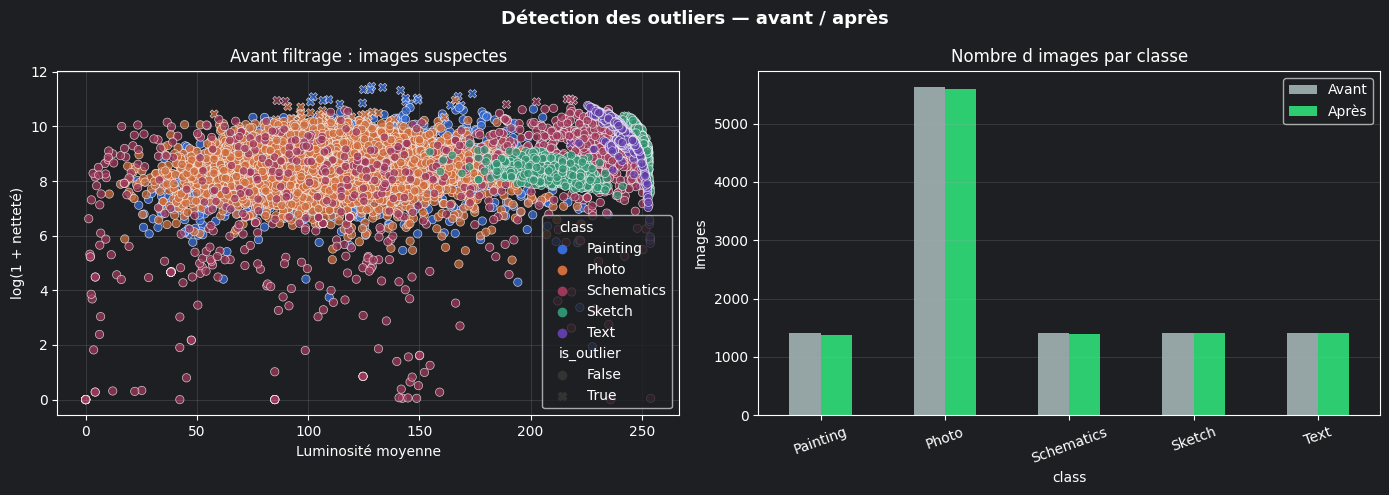

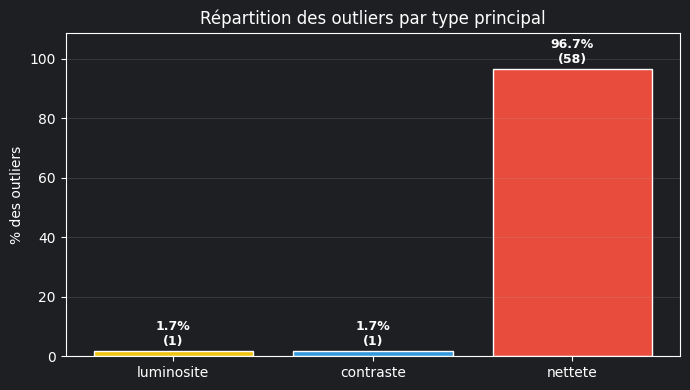

Outliers copiés dans : /home/aymen/DS/Leyenda/data/processed/outliers (60 fichier(s))


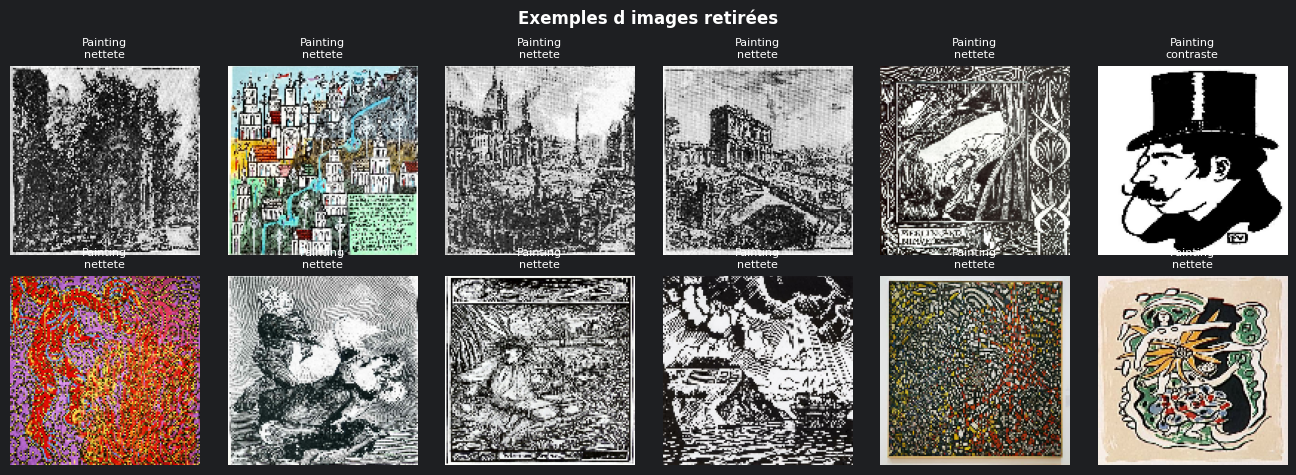

Dataset original : 11247 images
Dataset filtré   : 11187 images

 5 classes détectées : ['Painting', 'Photo', 'Schematics', 'Sketch', 'Text']
Classe             Train      Val     Test   % Test
----------------------------------------------------
Painting             886      221      277    20.0%
Photo               3581      895     1119    20.0%
Schematics           895      224      280    20.0%
Sketch               898      225      281    20.0%
Text                 899      225      281    20.0%


In [4]:
# -----------------------------------------------------------------
# CHARGEMENT DES DATASETS
# On charge d'abord en multi-classe (5 catégories) pour conserver
# la granularité et afficher les statistiques par catégorie.
# La conversion en binaire (Photo / Not_Photo) se fait ensuite.
# Split stratifié : 64% train / 16% val / 20% test
# -----------------------------------------------------------------
import numpy as np
import pandas as pd
import hashlib, shutil
from pathlib import Path
from sklearn.model_selection import train_test_split

EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

has_images = any(
    p.is_file() and p.suffix.lower() in EXTENSIONS
    for subfolder in DATA_RAW.iterdir() if subfolder.is_dir()
    for p in subfolder.rglob('*')
) if DATA_RAW.exists() else False

if not has_images:
    print(f"  Aucun fichier image trouvé dans {DATA_RAW}. "
          "Placez les images dans des sous-dossiers (ex: Photo, Painting, ...).")
    _empty = tf.data.Dataset.from_tensor_slices(
        (tf.zeros((0, IMAGE_H, IMAGE_W, 3), dtype=tf.float32),
         tf.zeros((0,), dtype=tf.int32))
    ).batch(BATCH_SIZE)
    train_multi = _empty
    val_multi   = _empty
    test_multi  = _empty
    class_names = []
    num_classes = 0
else:
    print(" Chargement des datasets...")

    # 1. Récupérer les classes dans le même ordre qu'image_dataset_from_directory
    #    (tri alphabétique des dossiers)
    class_names = sorted([d.name for d in DATA_RAW.iterdir() if d.is_dir()])
    num_classes = len(class_names)
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    # 2. Collecter tous les chemins et labels
    all_paths, all_labels = [], []
    for class_name in class_names:
        class_dir = DATA_RAW / class_name
        for p in class_dir.rglob('*'):
            if p.is_file() and p.suffix.lower() in EXTENSIONS:
                all_paths.append(str(p))
                all_labels.append(class_to_idx[class_name])

    all_paths  = np.array(all_paths)
    all_labels = np.array(all_labels)

    # 3. Détection / suppression des outliers avant split
    # Inspiré du workshop : statistiques simples par image + Z-score.
    # Le Z-score est calculé par classe pour éviter de supprimer une classe
    # entière simplement parce qu'elle a une texture/luminosité différente.
    OUTLIER_Z_THRESHOLD = 4.0
    OUTLIER_IMAGE_SIZE = 128
    OUTLIER_METRICS = ['mean', 'std', 'blur']

    def blur_score(img_arr):
        """Variance du Laplacien : score simple de netteté."""
        if img_arr.max() <= 1.0:
            img_arr = img_arr * 255.0
        gray = np.mean(img_arr, axis=-1)
        laplacian = (
            np.roll(gray, 1, axis=0) + np.roll(gray, -1, axis=0) +
            np.roll(gray, 1, axis=1) + np.roll(gray, -1, axis=1) -
            4 * gray
        )
        return float(laplacian.var())

    outlier_stats = []
    for path, label in zip(all_paths, all_labels):
        img = tf.io.read_file(path)
        img = tf.io.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, [OUTLIER_IMAGE_SIZE, OUTLIER_IMAGE_SIZE])
        arr = img.numpy().astype(np.float32)
        outlier_stats.append({
            'path': path,
            'label': int(label),
            'class': class_names[int(label)],
            'mean': float(arr.mean()),
            'std': float(arr.std()),
            'min': float(arr.min()),
            'max': float(arr.max()),
            'blur': blur_score(arr),
        })

    df_outlier_stats = pd.DataFrame(outlier_stats)

    def class_zscore(values):
        std = values.std(ddof=0)
        if std == 0 or np.isnan(std):
            return pd.Series(np.zeros(len(values)), index=values.index)
        return (values - values.mean()) / std

    for metric in OUTLIER_METRICS:
        z_col = f'{metric}_z'
        out_col = f'{metric}_outlier'
        df_outlier_stats[z_col] = df_outlier_stats.groupby('class')[metric].transform(class_zscore)
        df_outlier_stats[out_col] = df_outlier_stats[z_col].abs() > OUTLIER_Z_THRESHOLD

    outlier_cols = [f'{metric}_outlier' for metric in OUTLIER_METRICS]
    df_outlier_stats['is_outlier'] = df_outlier_stats[outlier_cols].any(axis=1)

    def outlier_reasons(row):
        reasons = []
        if row['mean_outlier']:
            reasons.append('luminosite')
        if row['std_outlier']:
            reasons.append('contraste')
        if row['blur_outlier']:
            reasons.append('nettete')
        return ', '.join(reasons) if reasons else 'normal'

    df_outlier_stats['reason'] = df_outlier_stats.apply(outlier_reasons, axis=1)

    reason_labels = {'mean': 'luminosite', 'std': 'contraste', 'blur': 'nettete'}

    def primary_outlier_type(row):
        triggered = [metric for metric in OUTLIER_METRICS if row[f'{metric}_outlier']]
        if not triggered:
            return 'normal'
        metric = max(triggered, key=lambda m: abs(row[f'{m}_z']))
        return reason_labels[metric]

    df_outlier_stats['primary_reason'] = df_outlier_stats.apply(primary_outlier_type, axis=1)
    before_counts = df_outlier_stats['class'].value_counts().reindex(class_names, fill_value=0)
    clean_df = df_outlier_stats[~df_outlier_stats['is_outlier']].copy()
    after_counts = clean_df['class'].value_counts().reindex(class_names, fill_value=0)
    n_outliers = int(df_outlier_stats['is_outlier'].sum())
    outlier_type_counts = (
        df_outlier_stats.loc[df_outlier_stats['is_outlier'], 'primary_reason']
        .value_counts()
        .reindex(['luminosite', 'contraste', 'nettete'], fill_value=0)
    )
    outlier_type_pct = outlier_type_counts / max(n_outliers, 1) * 100

    print(f"\nOutliers détectés : {n_outliers}/{len(df_outlier_stats)} images "
          f"(seuil Z={OUTLIER_Z_THRESHOLD})")
    if n_outliers:
        print(df_outlier_stats[df_outlier_stats['is_outlier']]
              .groupby(['class', 'reason']).size().to_string())
        print("\nRépartition principale des outliers :")
        for reason, pct in outlier_type_pct.items():
            print(f"  {reason:<10}: {outlier_type_counts[reason]} image(s) ({pct:.1f}%)")

    # Visualisation avant/après pour contrôler le filtrage.
    plot_df = df_outlier_stats.copy()
    plot_df['log_blur'] = np.log1p(plot_df['blur'])
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.scatterplot(
        data=plot_df, x='mean', y='log_blur', hue='class',
        style='is_outlier', alpha=0.75, ax=axes[0]
    )
    axes[0].set_title('Avant filtrage : images suspectes')
    axes[0].set_xlabel('Luminosité moyenne')
    axes[0].set_ylabel('log(1 + netteté)')
    axes[0].grid(True, alpha=0.25)

    pd.DataFrame({'Avant': before_counts, 'Après': after_counts}).plot(
        kind='bar', ax=axes[1], color=['#95a5a6', '#2ecc71']
    )
    axes[1].set_title('Nombre d images par classe')
    axes[1].set_ylabel('Images')
    axes[1].tick_params(axis='x', rotation=20)
    axes[1].grid(True, axis='y', alpha=0.25)
    plt.suptitle('Détection des outliers - avant / après', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'outliers_before_after.png', dpi=100, bbox_inches='tight')
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(
        outlier_type_pct.index,
        outlier_type_pct.values,
        color=['#f1c40f', '#3498db', '#e74c3c'],
        edgecolor='white'
    )
    for bar, pct, count in zip(bars, outlier_type_pct.values, outlier_type_counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            pct + 1,
            f"{pct:.1f}%\n({count})",
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )
    ax.set_ylim(0, max(10, float(outlier_type_pct.max()) + 12))
    ax.set_ylabel('% des outliers')
    ax.set_title('Répartition des outliers par type principal')
    ax.grid(True, axis='y', alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'outlier_type_percentages.png', dpi=100, bbox_inches='tight')
    plt.show()

    outlier_df = df_outlier_stats[df_outlier_stats['is_outlier']].copy()
    outlier_output_dir = DATA_PROC / 'outliers'
    outlier_output_dir.mkdir(parents=True, exist_ok=True)

    copied_outliers = 0
    outlier_manifest = []
    for _, row in outlier_df.iterrows():
        src_path = Path(row['path'])
        class_dir = outlier_output_dir / str(row['class'])
        class_dir.mkdir(parents=True, exist_ok=True)
        path_hash = hashlib.md5(str(src_path).encode('utf-8')).hexdigest()[:8]
        dest_name = f"{src_path.stem}__{row['primary_reason']}__{path_hash}{src_path.suffix.lower()}"
        dest_path = class_dir / dest_name
        shutil.copy2(str(src_path), str(dest_path))
        copied_outliers += 1
        outlier_manifest.append({
            'source_path': str(src_path),
            'copied_path': str(dest_path),
            'class': row['class'],
            'reason': row['reason'],
            'primary_reason': row['primary_reason'],
            'mean_z': row['mean_z'],
            'std_z': row['std_z'],
            'blur_z': row['blur_z'],
        })

    if outlier_manifest:
        pd.DataFrame(outlier_manifest).to_csv(outlier_output_dir / 'outliers_manifest.csv', index=False)

    print(f"Outliers copiés dans : {outlier_output_dir} ({copied_outliers} fichier(s))")

    if not outlier_df.empty:
        n_show = min(12, len(outlier_df))
        cols = 6
        rows = int(np.ceil(n_show / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.4))
        axes = np.atleast_1d(axes).ravel()

        for ax, (_, row) in zip(axes, outlier_df.head(n_show).iterrows()):
            raw = tf.io.read_file(row['path'])
            img = tf.io.decode_image(raw, channels=3, expand_animations=False)
            img = tf.image.resize(img, [OUTLIER_IMAGE_SIZE, OUTLIER_IMAGE_SIZE])
            ax.imshow(img.numpy().astype('uint8'))
            ax.set_title(str(row['class']) + '\n' + str(row['reason']), fontsize=8)
            ax.axis('off')

        for ax in axes[n_show:]:
            ax.axis('off')

        plt.suptitle('Exemples d images retirées', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'outliers_removed_samples.png', dpi=100, bbox_inches='tight')
        plt.show()

    all_paths = clean_df['path'].to_numpy()
    all_labels = clean_df['label'].to_numpy(dtype=np.int32)
    if len(all_paths) == 0:
        raise ValueError('Le filtrage des outliers a supprimé toutes les images.')

    print(f"Dataset original : {len(df_outlier_stats)} images")
    print(f"Dataset filtré   : {len(all_paths)} images")

    # 4. Split stratifié en deux étapes : 64% train / 16% val / 20% test
    #    Etape A : on isole 20% pour le test
    train_paths, test_paths, train_labels, test_labels = train_test_split(
        all_paths, all_labels,
        test_size    = 0.20,
        stratify     = all_labels,
        random_state = RANDOM_SEED
    )
    #    Etape B : sur les 80% restants, on prend 20% pour la val
    #    (0.20 * 0.80 = 0.16 du total -> val = 16% global)
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        train_paths, train_labels,
        test_size    = 0.20,
        stratify     = train_labels,
        random_state = RANDOM_SEED
    )

    # 5. Fonction de chargement identique à image_dataset_from_directory
    def load_image(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, [IMAGE_H, IMAGE_W])
        img = tf.cast(img, tf.float32)
        return img, label

    # 6. Construire les datasets
    train_multi = (
        tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
        .shuffle(1000, seed=RANDOM_SEED)
        .map(load_image, num_parallel_calls=1)
        .batch(BATCH_SIZE)
        .prefetch(1)
    )
    val_multi = (
        tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
        .map(load_image, num_parallel_calls=1)
        .batch(BATCH_SIZE)
        .prefetch(1)
    )
    test_multi = (
        tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
        .map(load_image, num_parallel_calls=1)
        .batch(BATCH_SIZE)
        .prefetch(1)
    )

    # 7. Vérification des proportions par classe
    print(f"\n {num_classes} classes détectées : {class_names}")
    print(f"{'Classe':15} {'Train':>8} {'Val':>8} {'Test':>8} {'% Test':>8}")
    print("-" * 52)
    for idx, name in enumerate(class_names):
        n_train = np.sum(train_labels == idx)
        n_val   = np.sum(val_labels == idx)
        n_test  = np.sum(test_labels == idx)
        total   = n_train + n_val + n_test
        pct     = n_test / total * 100
        print(f"{name:15} {n_train:>8} {n_val:>8} {n_test:>8} {pct:>7.1f}%")

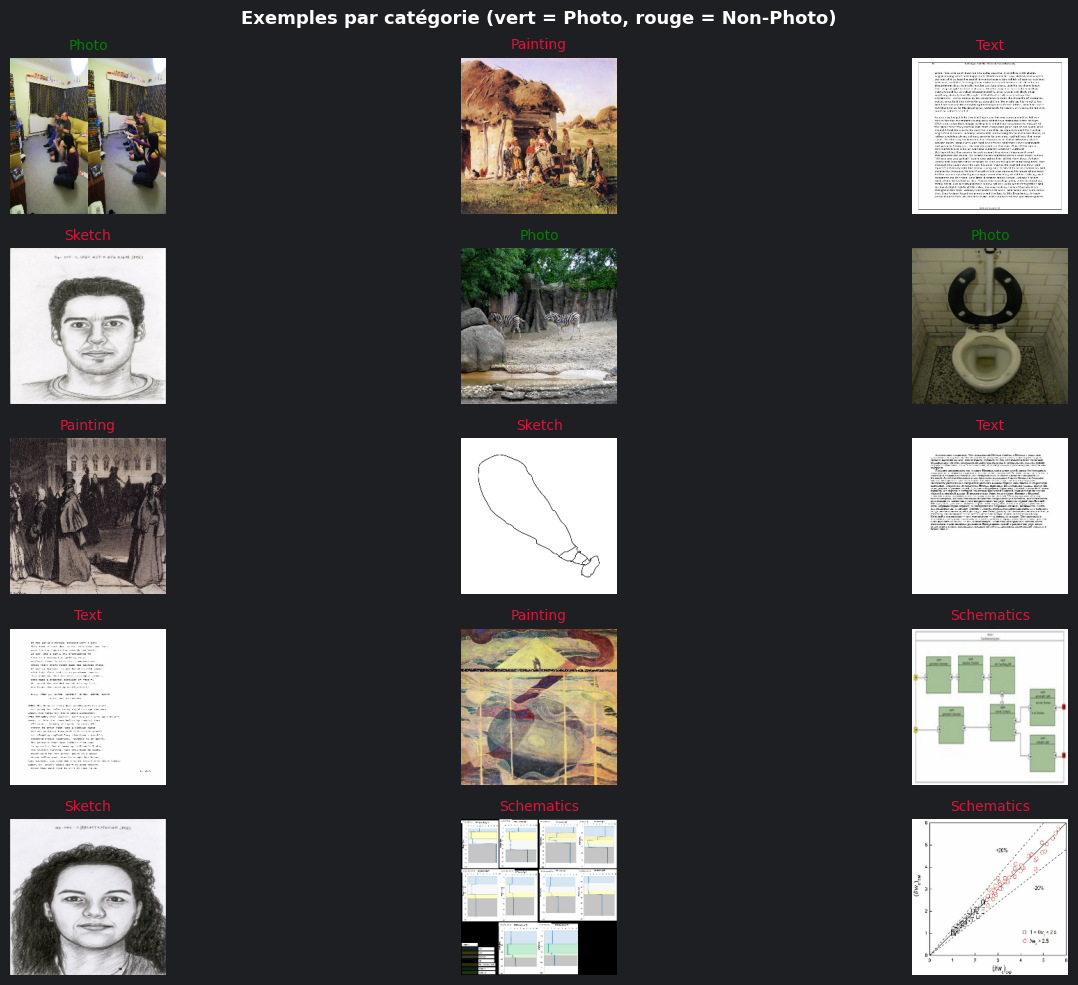

In [5]:
# -----------------------------------------------------------------
# VISUALISATION : grille d'exemples par classe
# Objectif : vérifier visuellement la qualité des données chargées
# et comprendre les différences visuelles entre les catégories.
# -----------------------------------------------------------------
if class_names:
    plt.figure(figsize=(16, 10))

    # Compteur pour s'assurer d'afficher exactement 3 images par classe
    seen = {name: 0 for name in class_names}
    images_shown = []

    # On parcourt les images (dépaquetées du batch avec .unbatch())
    # et on s'arrête quand on a 3 exemples de chaque classe
    for images, labels in train_multi.unbatch().take(200):
        lbl = class_names[labels.numpy()]
        if seen[lbl] < 3:
            # .numpy().astype('uint8') : convertit le tenseur TF en tableau NumPy
            # pour l'affichage matplotlib (valeurs pixels entières 0-255)
            images_shown.append((images.numpy().astype('uint8'), lbl))
            seen[lbl] += 1
        if all(v >= 3 for v in seen.values()):
            break  # On a assez d'images, on arrête de parcourir le dataset

    # Affichage en grille : num_classes lignes x 3 colonnes
    for i, (img, lbl) in enumerate(images_shown):
        ax = plt.subplot(num_classes, 3, i + 1)
        plt.imshow(img)
        # Vert = Photo (classe cible), Rouge = toutes les autres classes
        plt.title(lbl, fontsize=10,
                  color='green' if lbl == 'Photo' else 'crimson')
        plt.axis('off')

    plt.suptitle("Exemples par catégorie (vert = Photo, rouge = Non-Photo)",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'samples.png', dpi=100, bbox_inches='tight')
    plt.show()

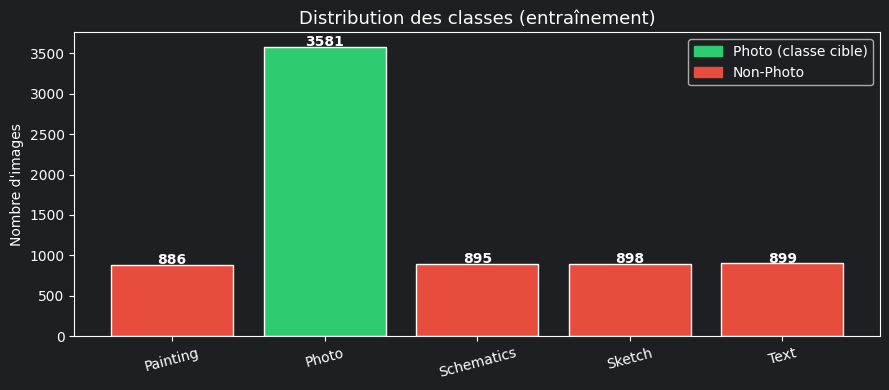


Photos     : 3581
Non-Photos : 3578  (ratio Non/Photo = 1.0x)


In [6]:
# -----------------------------------------------------------------
# DISTRIBUTION DES CLASSES
# Un déséquilibre important entre Photo et Non-Photo nécessite
# une correction (class_weight) pour éviter que le modèle
# n'apprenne à toujours prédire la classe majoritaire.
# -----------------------------------------------------------------
if class_names:
    # Comptage du nombre d'images par classe dans le jeu d'entraînement
    label_counts = {name: 0 for name in class_names}
    for _, labels in train_multi.unbatch():
        label_counts[class_names[labels.numpy()]] += 1

    # Couleur verte pour Photo, rouge pour les autres classes
    colors = ['#2ecc71' if k == 'Photo' else '#e74c3c' for k in label_counts]

    plt.figure(figsize=(9, 4))
    bars = plt.bar(label_counts.keys(), label_counts.values(),
                   color=colors, edgecolor='white')

    # Affiche le nombre exact au-dessus de chaque barre
    for bar, v in zip(bars, label_counts.values()):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(v), ha='center', fontsize=10, fontweight='bold')

    plt.title("Distribution des classes (entraînement)", fontsize=13)
    plt.ylabel("Nombre d'images")
    plt.xticks(rotation=15)

    # Légende manuelle avec des patches colorés
    photo_patch    = mpatches.Patch(color='#2ecc71', label='Photo (classe cible)')
    nonphoto_patch = mpatches.Patch(color='#e74c3c', label='Non-Photo')
    plt.legend(handles=[photo_patch, nonphoto_patch])
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'distribution.png', dpi=100)
    plt.show()

    # Calcul du ratio de déséquilibre entre les deux grandes classes binaires
    n_photo    = label_counts.get('Photo', 0)
    n_nonphoto = sum(v for k, v in label_counts.items() if k != 'Photo')
    ratio = n_nonphoto / max(n_photo, 1)  # max(..., 1) évite la division par zéro

    print(f"\nPhotos     : {n_photo}")
    print(f"Non-Photos : {n_nonphoto}  (ratio Non/Photo = {ratio:.1f}x)")

    # Si Non-Photo est 2x plus représenté que Photo, le modèle risque de
    # pénaliser peu les erreurs sur Photo -> on corrige avec class_weight
    if ratio > 2:
        print("  Dataset déséquilibré -> class_weight appliqué à l'entraînement")
else:
    n_photo = n_nonphoto = 0

---
## 4. Préparation des données binaires

### Regroupement des 5 classes en 2

| Classe d'origine | Label binaire | Raison du regroupement |
|---|---|---|
| **Photo** | **1** (positif) | Classe cible - ce que le modèle doit détecter |
| Painting | **0** (négatif) | Non-photo |
| Schematics | **0** (négatif) | Non-photo |
| Sketch | **0** (négatif) | Non-photo |
| Text | **0** (négatif) | Non-photo |

### Pourquoi regrouper en binaire plutôt que rester en 5 classes ?

L'objectif métier est **"photo ou non ?"** - distinguer une peinture d'un schéma n'a pas de valeur ajoutée.
Regrouper les 4 classes Non-Photo :
- **Augmente les exemples négatifs** disponibles -> modèle plus robuste
- **Simplifie la tâche** -> meilleure précision sur la décision principale
- **Réduit les risques de confusion** inter-classes Non-Photo

### Correction du déséquilibre par `class_weight`

Si Photo représente 30% du dataset, un modèle naïf peut atteindre 70% d'accuracy en prédisant
**toujours** Not_Photo. La correction par `class_weight` corrige cela :

```
weight_classe = total / (nb_classes x n_classe)
```

| Classe | n_classe | weight (si n_photo=3000, n_nonphoto=7000) |
|---|---|---|
| Photo (1) | 3 000 | 10 000 / (2 x 3 000) = **1.67** |
| Not_Photo (0) | 7 000 | 10 000 / (2 x 7 000) = **0.71** |

La classe minoritaire reçoit un poids > 1 : chaque erreur sur une photo "coûte" plus cher
dans la fonction de perte, forçant le modèle à s'y attarder davantage.

### Pipeline binaire - optimisations

`.cache()` est ajouté après la conversion binaire : comme la conversion est déterministe,
on peut mettre en cache le résultat après la première époque et éviter de recalculer à chaque fois.
`.shuffle()` uniquement sur le train - jamais sur val/test pour garantir des résultats reproductibles.

### Pourquoi on ne standardise pas les images

Dans ce notebook, les pixels sont **normalisés par rescaling** avec :

```python
layers.Rescaling(1./255)
```

Cela transforme les valeurs de pixels de `[0, 255]` vers `[0, 1]`, ce qui suffit pour stabiliser
l'entraînement du CNN :

$$
x_{rescale} = \frac{x}{255}
$$

On ne fait pas de standardisation globale du type :

$$
x_{standardise} = \frac{x - \mu_{dataset}}{\sigma_{dataset}}
$$

pour trois raisons :

| Raison | Explication |
|---|---|
| **Images très hétérogènes** | Le dataset mélange photos, peintures, schémas, croquis et textes. Une moyenne globale aurait peu de sens visuel. |
| **Conservation des contrastes utiles** | Les différences de luminosité, couleur et texture aident justement à distinguer Photo / Not_Photo. |
| **BatchNormalization déjà présente** | Le modèle normalise les activations internes après les couches convolutives, ce qui réduit le besoin d'une standardisation forte en entrée. |

Le choix retenu est donc :

```text
Entrée image brute -> resize 224x224 -> Rescaling(1./255) -> CNN + BatchNormalization
```

Cette stratégie est simple, robuste, compatible avec l'augmentation de données, et évite
d'introduire un biais artificiel lié à une moyenne calculée sur des classes visuellement très différentes.


In [7]:
# -----------------------------------------------------------------
# CONVERSION MULTI-CLASSE -> BINAIRE
# -----------------------------------------------------------------

# Récupère l'indice numérique de la classe "Photo" dans la liste des classes
# (l'ordre dépend du tri alphabétique des dossiers)
photo_idx = class_names.index('Photo') if 'Photo' in class_names else 0
print(f"Index 'Photo' dans class_names : {photo_idx}")

def to_binary(images, labels):
    """Photo -> 1, tout le reste -> 0."""
    # tf.cast convertit un tenseur booléen en entier :
    # (labels == photo_idx) -> True/False -> 1/0
    return images, tf.cast(labels == photo_idx, tf.int32)

# AUTOTUNE laisse TensorFlow choisir automatiquement le niveau
# de parallélisme optimal selon les ressources disponibles (CPU/GPU)
AUTOTUNE = tf.data.AUTOTUNE

# --- Calcul des class weights (correction du déséquilibre) ---
# Formule : weight_classe = total / (nb_classes x n_classe)
# -> La classe minoritaire reçoit un poids > 1 (plus pénalisante si q classée)
# -> La classe majoritaire reçoit un poids < 1 (moins pénalisante)
total = n_photo + n_nonphoto
weight_photo    = total / (2 * n_photo)    if n_photo    > 0 else 1.0
weight_nonphoto = total / (2 * n_nonphoto) if n_nonphoto > 0 else 1.0
class_weight = {0: weight_nonphoto, 1: weight_photo}
print(f"\nClass weights : {class_weight}")
print("  (valeur > 1 = classe minoritaire)")

# --- Pipeline d'optimisation des données ---
# .map()     : applique la conversion binaire à chaque batch en parallèle
# .cache() est volontairement evite ici : les images 224x224x3 en float32
# consomment plusieurs Go et peuvent faire redemarrer le kernel sous WSL.
# Le shuffle est deja fait dans train_multi avant le decodage des images.
# On ne reshuffle pas ici : apres batching, le buffer contiendrait de gros tenseurs image.
# .prefetch(1): prepare seulement un batch d'avance pour limiter la RAM.
train_bin = (train_multi
    .map(to_binary, num_parallel_calls=1)
    .prefetch(1)
)
# Pas de shuffle sur la validation : on veut des résultats stables et reproductibles
# Pas de shuffle sur la validation/test : on veut des resultats stables et reproductibles
val_bin = (val_multi
    .map(to_binary, num_parallel_calls=1)
    .prefetch(1)
)
test_bin = (test_multi
    .map(to_binary, num_parallel_calls=1)
    .prefetch(1)
)

print("\n Datasets binaires prêts.")
print("  train_bin : apprentissage")
print("  val_bin   : validation / choix du seuil")
print("  test_bin  : evaluation finale")
print("  1 = Photo")
print("  0 = Not_Photo (Painting, Schematics, Sketch, Text)")

Index 'Photo' dans class_names : 1

Class weights : {0: 1.0004192286193405, 1: 0.9995811225914549}
  (valeur > 1 = classe minoritaire)

 Datasets binaires prêts.
  train_bin : apprentissage
  val_bin   : validation / choix du seuil
  test_bin  : evaluation finale
  1 = Photo
  0 = Not_Photo (Painting, Schematics, Sketch, Text)


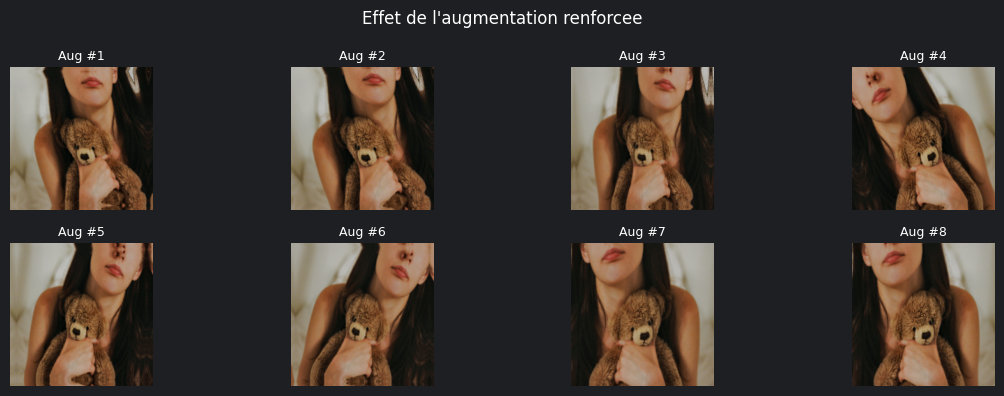

In [8]:
# -----------------------------------------------------------------
# AUGMENTATION DES DONNEES - version renforcee
# Augmentation plus agressive pour forcer la generalisation :
# la val_loss montait des l'epoque 1 -> le modele memorisait trop vite.
# On augmente les amplitudes pour creer plus de variabilite.
# -----------------------------------------------------------------
data_augmentation = Sequential([
    RandomFlip('horizontal'),
    RandomRotation(0.05),   # ±18 deg - beaucoup plus réaliste
    RandomZoom(0.1),        # ±10% - suffisant
    RandomContrast(0.1),    # léger - évite les images trop dégradées
], name='augmentation')

plt.figure(figsize=(12, 4))
for images, _ in train_bin.take(1):
    img = images[0:1]
    for i in range(8):
        aug = data_augmentation(img, training=True)
        ax = plt.subplot(2, 4, i + 1)
        plt.imshow(aug[0].numpy().astype('uint8'))
        plt.title(f'Aug #{i+1}', fontsize=9)
        plt.axis('off')
plt.suptitle("Effet de l'augmentation renforcee", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'augmentation.png', dpi=100)
plt.show()

---
## 5. Modèle CNN from scratch

### Pourquoi un CNN from scratch ?

| Approche | Avantages | Inconvénients | Quand l'utiliser |
|---|---|---|---|
| **CNN from scratch** (choix ici) | Adapté au domaine, contrôle total | Plus lent à converger | Dataset > 5 000 images, domaine spécifique |
| Transfer Learning (EfficientNet, ResNet) | Converge vite, bons résultats dès le départ | Biais ImageNet, moins adapté au domaine | Peu de données, domaine proche de photos naturelles |

Notre dataset Leyenda présente des cas difficiles (peintures hyper-réalistes) qui **diffèrent
significativement** du domaine ImageNet -> un CNN from scratch est justifié.
Si les performances restaient insuffisantes (AUC < 0.90), EfficientNetB0 serait la piste suivante.

### Architecture détaillée

```
Input (224 x 224 x 3)
  |
  +-- [Augmentation Layer]
  |     RandomFlip + RandomRotation(0.05) + RandomZoom(0.1) + RandomContrast(0.1)
  |
  +-- Rescaling(/255)           -> pixels normalisés dans [0, 1]
  |
  +-- Conv2D(32,  3x3) -> relu   -> détecte : bords, gradients de couleur
  |   BatchNormalization         -> normalise les activations
  |   MaxPooling(2x2)            -> 224x224 -> 112x112
  |
  +-- Conv2D(64,  3x3) -> relu   -> détecte : textures simples, motifs répétitifs
  |   BatchNormalization
  |   MaxPooling(2x2)            -> 112x112 -> 56x56
  |
  +-- Conv2D(128, 3x3) -> relu   -> détecte : textures complexes (grain photo, coups de pinceau)
  |   BatchNormalization
  |   MaxPooling(2x2)            -> 56x56 -> 28x28
  |
  +-- Conv2D(256, 3x3) -> relu   -> détecte : combinaisons de features (structure d'une photo vs peinture)
  |   BatchNormalization
  |   MaxPooling(2x2)            -> 28x28 -> 14x14
  |
  +-- GlobalAveragePooling2D    -> 14x14x256 -> vecteur de 256 dims (moyenne spatiale)
  |
  +-- Dense(128, relu) + BatchNorm + Dropout(0.5)   -> classifieur intermédiaire
  +-- Dense(64,  relu) + BatchNorm + Dropout(0.3)   -> compression vers la décision
  +-- Dense(1, sigmoid)         -> P(Photo) ∈ [0, 1]
```

### Lecture mathématique d'une convolution

Une couche `Conv2D` applique un noyau appris sur l'image. Pour une carte de features $X$ et un noyau $K$, une activation peut s'écrire :

$$
Y_{i,j,k} = \sigma\left( b_k + \sum_{u,v,c} K_{u,v,c,k}\,X_{i+u,j+v,c} \right)
$$

où $\sigma$ est ici principalement `relu`. Les premières couches apprennent des motifs simples, puis les couches profondes combinent ces motifs en textures et structures plus abstraites.

### Justification de chaque choix architectural

| Elément | Valeur choisie | Justification |
|---|---|---|
| Filtres Conv | 32 -> 64 -> 128 -> 256 | Doublement progressif : features simples vers complexes |
| Kernel size | 3x3 | Standard - bon rapport expressivité / nombre de paramètres |
| Padding | `same` | Conserve les dimensions spatiales -> pas de perte d'info sur les bords |
| Activation | relu | Evite la disparition du gradient (vs sigmoid/tanh dans les couches cachées) |
| L2 (1e-4) | Tous les Conv et Dense | Pénalise les poids trop grands -> limite la mémorisation |
| GlobalAveragePooling | Après les Conv | Réduit ~90% des paramètres vs Flatten, robuste aux translations |
| Dropout(0.5) | Avant Dense(64) | Désactive 50% des connexions -> force la redondance des features |
| Adam lr=1e-4 | Optimizer | Conservateur : lr=1e-3 produisait de l'instabilité sur val_loss |
| BinaryCrossentropy | Loss | Standard pour une sortie sigmoid binaire |
| AUC comme métrique | Suivi | Insensible au seuil de décision -> mesure réelle de discrimination |

La cellule suivante (15) affiche ce diagramme sous forme graphique matplotlib.

### Choix des fonctions d'activation et des hyperparamètres

#### Fonctions d'activation possibles

| Fonction | Usage typique | Avantage | Limite | Choix dans ce projet |
|---|---|---|---|---|
| **ReLU** | Couches cachées CNN / Dense | Simple, rapide, limite le problème de gradient qui disparaît | Peut produire des neurones inactifs si mal réglée | **Utilisée** dans les couches `Conv2D` et `Dense` |
| **Sigmoid** | Sortie binaire | Produit une probabilité entre 0 et 1 | Moins adaptée aux couches profondes cachées | **Utilisée** en sortie pour `P(Photo)` |
| **Tanh** | Couches cachées centrées autour de 0 | Sortie entre -1 et 1 | Plus coûteuse, saturation possible | Non retenue : ReLU est plus standard pour CNN |
| **Softmax** | Classification multiclasse exclusive | Donne une distribution de probabilité sur plusieurs classes | Pas adaptée à une sortie binaire unique | Non retenue ici : objectif Photo / Not_Photo |

Le problème est binaire. On veut donc une seule probabilité :

$$
\hat{y}=P(\text{Photo}\mid x)
$$

La règle de décision est :

$$
\hat{c} =
\begin{cases}
\text{Photo} & \text{si } \hat{y} \ge \tau \\
\text{Not\_Photo} & \text{si } \hat{y} < \tau
\end{cases}
$$

où $\tau$ est le seuil de décision.

C'est pourquoi la dernière couche utilise une sigmoid :

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

#### Hyperparamètres retenus

| Hyperparamètre | Valeur | Justification |
|---|---:|---|
| Taille image | `224 x 224` | Compromis entre détail visuel et coût mémoire/calcul |
| Batch size | `32` | Valeur standard, stable pour l'entraînement CNN |
| Epochs max | `5` | Entraînement court contrôlé par EarlyStopping |
| Learning rate | `1e-4` | Plus prudent que `1e-3`, limite les oscillations de la loss |
| Optimizer | `Adam` | Bon choix par défaut : adapte le pas d'apprentissage par paramètre |
| Filtres Conv2D | `32, 64, 128, 256` | Capacité croissante : bords simples puis textures/formes complexes |
| Dense units | `128`, puis `64` | Suffisant pour combiner les features sans trop augmenter les paramètres |
| Dropout | `0.5`, puis `0.3` | Réduit le sur-apprentissage dans les couches denses |
| L2 | `1e-4` | Pénalise les poids trop grands et améliore la généralisation |

Ces choix privilégient un modèle **assez expressif** pour distinguer les peintures réalistes des photos,
mais régularisé pour éviter de mémoriser le jeu d'entraînement.


In [9]:
def build_cnn(input_shape=(IMAGE_H, IMAGE_W, 3)):
    """CNN binaire régularisé : L2, BatchNorm, Dropout et learning rate réduit."""
    # Regularisation L2 appliquee aux filtres Conv :
    # penalise les poids trop grands -> evite la memorisation
    l2 = tf.keras.regularizers.l2(1e-4)

    model = Sequential(name='CNN_Scratch')

    # Augmentation + normalisation
    model.add(data_augmentation)
    model.add(layers.Rescaling(1./255, input_shape=input_shape))

    # 4 blocs convolutifs avec regularisation
    for filters in [32, 64, 128, 256]:
        model.add(Conv2D(filters, 3, padding='same', activation='relu',
                         kernel_regularizer=l2))
        model.add(BatchNormalization())
        model.add(MaxPooling2D(2))

    model.add(GlobalAveragePooling2D())

    # Dense reduit de 256 -> 128 : moins de parametres = moins d'overfitting
    model.add(Dense(128, activation='relu', kernel_regularizer=l2))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))   # dropout fort avant la sortie

    model.add(Dense(64, activation='relu', kernel_regularizer=l2))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))
    
    # Sortie binaire
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer = tf.keras.optimizers.Adam(1e-4),
        loss      = tf.keras.losses.BinaryCrossentropy(),
        metrics   = [
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model


model_cnn = build_cnn()
model_cnn.summary()

Model: "CNN_Scratch"

+=================================+========================+===============+
| Layer (type)                    | Output Shape           |       Param # |
+=================================+========================+===============+
| augmentation (Sequential)       | (1, 224, 224, 3)       |             0 |
+---------------------------------+------------------------+---------------+
| rescaling (Rescaling)           | (1, 224, 224, 3)       |             0 |
+---------------------------------+------------------------+---------------+
| conv2d (Conv2D)                 | (1, 224, 224, 32)      |           896 |
+---------------------------------+------------------------+---------------+
| batch_normalization             | (1, 224, 224, 32)      |           128 |
| (BatchNormalization)            |                        |               |
+---------------------------------+------------------------+---------------+
| max_pooling2d (MaxPooling2D)    | (1, 112, 112, 32)      |             0 |
+---------------------------------+------------------------+---------------+
| conv2d_1 (Conv2D)               | (1, 112, 112, 64)      |        18,496 |
+---------------------------------+------------------------+---------------+
| batch_normalization_1           | (1, 112, 112, 64)      |           256 |
| (BatchNormalization)            |                        |               |
+---------------------------------+------------------------+---------------+
| max_pooling2d_1 (MaxPooling2D)  | (1, 56, 56, 64)        |             0 |
+---------------------------------+------------------------+---------------+
| conv2d_2 (Conv2D)               | (1, 56, 56, 128)       |        73,856 |
+---------------------------------+------------------------+---------------+
| batch_normalization_2           | (1, 56, 56, 128)       |           512 |
| (BatchNormalization)            |                        |               |
+---------------------------------+------------------------+---------------+
| max_pooling2d_2 (MaxPooling2D)  | (1, 28, 28, 128)       |             0 |
+---------------------------------+------------------------+---------------+
| conv2d_3 (Conv2D)               | (1, 28, 28, 256)       |       295,168 |
+---------------------------------+------------------------+---------------+
| batch_normalization_3           | (1, 28, 28, 256)       |         1,024 |
| (BatchNormalization)            |                        |               |
+---------------------------------+------------------------+---------------+
| max_pooling2d_3 (MaxPooling2D)  | (1, 14, 14, 256)       |             0 |
+---------------------------------+------------------------+---------------+
| global_average_pooling2d        | (1, 256)               |             0 |
| (GlobalAveragePooling2D)        |                        |               |
+---------------------------------+------------------------+---------------+
| dense (Dense)                   | (1, 128)               |        32,896 |
+---------------------------------+------------------------+---------------+
| batch_normalization_4           | (1, 128)               |           512 |
| (BatchNormalization)            |                        |               |
+---------------------------------+------------------------+---------------+
| dropout (Dropout)               | (1, 128)               |             0 |
+---------------------------------+------------------------+---------------+
| dense_1 (Dense)                 | (1, 64)                |         8,256 |
+---------------------------------+------------------------+---------------+
| batch_normalization_5           | (1, 64)                |           256 |
| (BatchNormalization)            |                        |               |
+---------------------------------+------------------------+---------------+
| dropout_1 (Dropout)             | (1, 64)                |             0 |
+---------------------------------+------------------------+-------------

 Total params: 432,321 (1.65 MB)

 Trainable params: 430,977 (1.64 MB)

 Non-trainable params: 1,344 (5.25 KB)

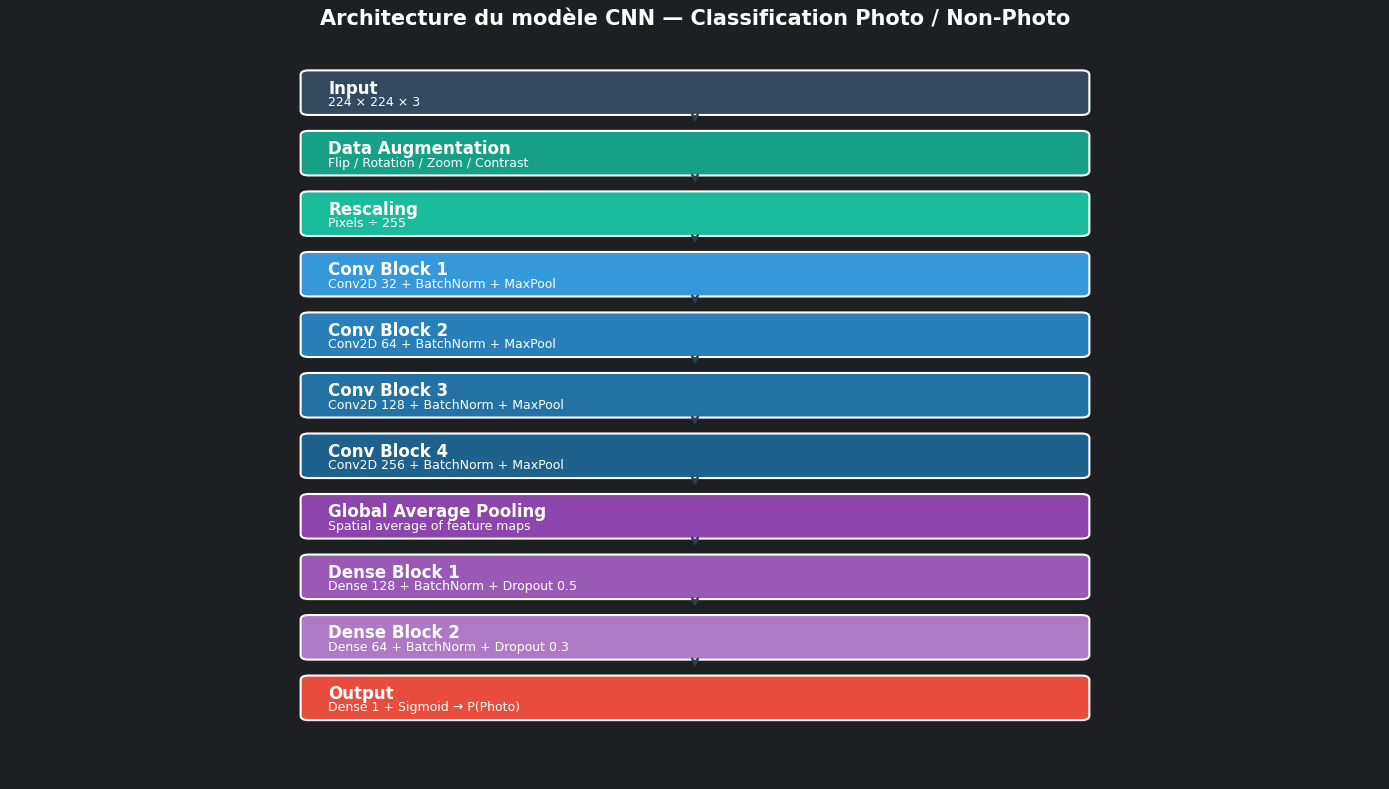

In [10]:
# ============================================================
# Option 3 - Custom Matplotlib Diagram
# Clean presentation-style schema, no extra dependency
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as patches

layers_schema = [
    ("Input", "224 x 224 x 3", "#34495e"),
    ("Data Augmentation", "Flip / Rotation / Zoom / Contrast", "#16a085"),
    ("Rescaling", "Pixels / 255", "#1abc9c"),
    ("Conv Block 1", "Conv2D 32 + BatchNorm + MaxPool", "#3498db"),
    ("Conv Block 2", "Conv2D 64 + BatchNorm + MaxPool", "#2980b9"),
    ("Conv Block 3", "Conv2D 128 + BatchNorm + MaxPool", "#2471a3"),
    ("Conv Block 4", "Conv2D 256 + BatchNorm + MaxPool", "#1f618d"),
    ("Global Average Pooling", "Spatial average of feature maps", "#8e44ad"),
    ("Dense Block 1", "Dense 128 + BatchNorm + Dropout 0.5", "#9b59b6"),
    ("Dense Block 2", "Dense 64 + BatchNorm + Dropout 0.3", "#af7ac5"),
    ("Output", "Dense 1 + Sigmoid -> P(Photo)", "#e74c3c"),
]

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, len(layers_schema) * 1.2)
ax.axis("off")

box_x = 3.0
box_w = 8.0
box_h = 0.75
y_start = len(layers_schema) * 1.1

for i, (name, detail, color) in enumerate(layers_schema):
    y = y_start - i * 1.1

    box = patches.FancyBboxPatch(
        (box_x, y),
        box_w,
        box_h,
        boxstyle="round,pad=0.03,rounding_size=0.08",
        linewidth=1.5,
        edgecolor="white",
        facecolor=color
    )
    ax.add_patch(box)

    ax.text(
        box_x + 0.25,
        y + box_h * 0.62,
        name,
        color="white",
        fontsize=12,
        fontweight="bold",
        va="center"
    )

    ax.text(
        box_x + 0.25,
        y + box_h * 0.28,
        detail,
        color="white",
        fontsize=9,
        va="center"
    )

    if i < len(layers_schema) - 1:
        ax.annotate(
            "",
            xy=(box_x + box_w / 2, y - 0.22),
            xytext=(box_x + box_w / 2, y),
            arrowprops=dict(arrowstyle="->", color="#2c3e50", linewidth=1.8)
        )

ax.set_title(
    "Architecture du modèle CNN - Classification Photo / Non-Photo",
    fontsize=15,
    fontweight="bold",
    pad=20
)

plt.tight_layout()

custom_schema_path = FIGURES_DIR / "model_schema_custom.png"
plt.savefig(custom_schema_path, dpi=140, bbox_inches="tight")
plt.show()

### Fonction de loss et minimisation

#### Pourquoi `binary_crossentropy` ?

Le modèle doit résoudre une **classification binaire** :

$$
y =
\begin{cases}
1 & \text{si l'image est une Photo} \\
0 & \text{sinon}
\end{cases}
$$

La sortie du réseau est une probabilité :

```python
Dense(1, activation='sigmoid')
```

Donc la fonction de perte adaptée est la **binary crossentropy** :

$$
\mathcal{L}(y,p) = -\left[y\log(p) + (1-y)\log(1-p)\right]
$$

Sur un dataset de $N$ images, la loss moyenne optimisée est :

$$
\mathcal{J}(\theta)=\frac{1}{N}\sum_{i=1}^{N}\mathcal{L}(y_i,p_i)
$$

où :

| Symbole | Signification |
|---|---|
| `y` | vraie classe : 0 ou 1 |
| `p` | probabilité prédite par le modèle : `P(Photo)` |

Cette loss pénalise fortement les erreurs confiantes :

| Exemple | Interprétation | Loss |
|---|---|---|
| vraie Photo, `P(Photo)=0.99` | bonne prédiction confiante | faible |
| vraie Photo, `P(Photo)=0.10` | mauvaise prédiction confiante | forte |
| vraie Not_Photo, `P(Photo)=0.95` | faux positif très confiant | forte |

On n'utilise pas `categorical_crossentropy` car elle est destinée à une sortie multiclasse avec `softmax`.
Ici, une seule sortie sigmoid suffit pour décider Photo / Not_Photo.

#### Comment la loss est minimisée

L'entraînement cherche les poids du réseau qui minimisent la loss moyenne sur le train set :

$$
\theta^* = \arg\min_{\theta}\mathcal{J}(\theta)
$$

A chaque batch :

```text
1. Forward pass       : le CNN calcule P(Photo)
2. Calcul de la loss  : comparaison entre prédiction et vraie étiquette
3. Backpropagation    : calcul des gradients de la loss par rapport aux poids
4. Adam optimizer     : mise à jour des poids avec learning rate = 1e-4
```

`Adam` est utilisé car il adapte automatiquement l'amplitude des mises à jour pour chaque paramètre.
Cela rend l'entraînement plus stable qu'une descente de gradient simple, surtout avec un CNN contenant
plusieurs blocs convolutifs et des couches denses.

Les callbacks complètent cette minimisation :

| Callback | Rôle |
|---|---|
| `EarlyStopping` | arrête l'entraînement si la validation ne s'améliore plus |
| `ReduceLROnPlateau` | réduit le learning rate quand la loss stagne |
| `ModelCheckpoint` | sauvegarde les meilleurs poids selon `val_loss` |

Ainsi, le modèle minimise la loss tout en limitant le risque de sur-apprentissage.


In [11]:
# -----------------------------------------------------------------
# CALLBACKS - surveille val_loss (plus fiable que val_auc ici)
# La val_loss montait des l'epoque 2 avec la config precedente.
# On surveille sa degradation pour stopper avant que ca empire.
# -----------------------------------------------------------------
def get_callbacks(name, patience_stop=10, patience_lr=5):
    return [
        # EarlyStopping sur val_loss (mode='min') :
        # arrete si la val_loss ne descend plus -> evite de continuer
        # a memoriser le train pendant que la validation se degrade.
        EarlyStopping(
            monitor='val_loss', mode='min',
            patience=patience_stop,
            restore_best_weights=True, verbose=1
        ),

        # ReduceLROnPlateau : divise le lr par 2 si val_loss stagne
        # factor=0.5 et patience=5 -> reagit plus rapidement aux plateaux
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=patience_lr, min_lr=1e-7, verbose=1
        ),

        # Sauvegarde le meilleur checkpoint selon val_loss
        ModelCheckpoint(
            str(MODELS_DIR / f'{name}_best.keras'),
            monitor='val_loss', mode='min',
            save_best_only=True, verbose=0
        )
    ]

print("Callbacks mis a jour :")
print("  EarlyStopping      patience=10  (sur val_loss, mode=min)")
print("  ReduceLROnPlateau  patience=5   (divise lr si val_loss stagne)")
print("  ModelCheckpoint    -> sauvegarde le meilleur val_loss")

Callbacks mis a jour :
  EarlyStopping      patience=10  (sur val_loss, mode=min)
  ReduceLROnPlateau  patience=5   (divise lr si val_loss stagne)
  ModelCheckpoint    -> sauvegarde le meilleur val_loss


In [12]:
print(" Entraînement du CNN...\n")

def current_ram_mb():
    try:
        with open('/proc/self/status', 'r') as f:
            for line in f:
                if line.startswith('VmRSS:'):
                    return int(line.split()[1]) / 1024
    except Exception:
        return float('nan')
    return float('nan')

class RamLogger(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        print(f"[RAM] Debut epoch {epoch + 1}: {current_ram_mb():.1f} MB", flush=True)

    def on_epoch_end(self, epoch, logs=None):
        print(f"[RAM] Fin epoch {epoch + 1}: {current_ram_mb():.1f} MB", flush=True)


class TestMetricsLogger(tf.keras.callbacks.Callback):
    """Evalue le test set à chaque époque pour tracer train/test loss et accuracy."""
    def __init__(self, test_dataset):
        super().__init__()
        self.test_dataset = test_dataset
        self.history = {'test_loss': [], 'test_accuracy': []}

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        test_results = self.model.evaluate(self.test_dataset, verbose=0, return_dict=True)
        self.history['test_loss'].append(float(test_results['loss']))
        self.history['test_accuracy'].append(float(test_results['accuracy']))
        logs['test_loss'] = float(test_results['loss'])
        logs['test_accuracy'] = float(test_results['accuracy'])
        print(
            f" - test_loss: {test_results['loss']:.4f}"
            f" - test_accuracy: {test_results['accuracy']:.4f}"
        )


test_metrics_logger = TestMetricsLogger(test_bin)

# model.fit() lance la boucle d'entraînement :
#   train_bin        : dataset d'entraînement binaire (images + labels 0/1)
#   validation_data  : dataset de validation (évalué à la fin de chaque époque,
#                      pas utilisé pour mettre à jour les poids)
#   test_metrics_logger : évalue le test set à chaque époque uniquement pour
#                         produire les courbes demandées dans le livrable.
#   epochs           : nombre maximum d'époques (l'EarlyStopping peut arrêter avant)
#   callbacks        : liste des mécanismes automatiques définis ci-dessus
#   class_weight     : poids par classe pour compenser le déséquilibre Photo/Non-Photo
#                      -> la perte est multipliée par ce poids pour chaque exemple
#   verbose=1        : affiche une barre de progression par époque
history_cnn = model_cnn.fit(
    train_bin,
    validation_data = val_bin,
    epochs          = EPOCHS_CNN,
    callbacks       = get_callbacks('cnn_scratch') + [RamLogger(), test_metrics_logger],
    class_weight    = class_weight,
    verbose         = 1
)
# history_cnn.history est un dictionnaire contenant les métriques
# enregistrées à chaque époque : 'accuracy', 'val_accuracy', 'loss', 'val_loss', etc.
print("\n Entraînement terminé.")

 Entraînement du CNN...

[RAM] Debut epoch 1: 1668.0 MB
Epoch 1/20


I0000 00:00:1780265390.953443  304971 cuda_dnn.cc:461] Loaded cuDNN version 92200
W0000 00:00:1780265392.271610  304971 bfc_allocator.cc:383] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performance overhead. You may try smaller batch sizes to observe the performance impact. Set TF_ENABLE_GPU_GARBAGE_COLLECTION=false if you'd like to disable this feature.


  1/224 ==================== 44:11 12s/step - accuracy: 0.5000 - auc: 0.5412 - loss: 0.9800 - precision: 0.5238 - recall: 0.6471

W0000 00:00:1780265397.123477  304972 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 776.38MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


224/224 ==================== 0s 193ms/step - accuracy: 0.8024 - auc: 0.8597 - loss: 0.5488 - precision: 0.7732 - recall: 0.8565[RAM] Fin epoch 1: 2953.1 MB
 - test_loss: 0.7017 - test_accuracy: 0.5018
224/224 ==================== 71s 266ms/step - accuracy: 0.8141 - auc: 0.8764 - loss: 0.5174 - precision: 0.7870 - recall: 0.8615 - val_accuracy: 0.5034 - val_auc: 0.8712 - val_loss: 0.7037 - val_precision: 0.8000 - val_recall: 0.0089 - learning_rate: 1.0000e-04 - test_loss: 0.7017 - test_accuracy: 0.5018
[RAM] Debut epoch 2: 3095.1 MB
Epoch 2/20
224/224 ==================== 0s 182ms/step - accuracy: 0.8296 - auc: 0.9039 - loss: 0.4613 - precision: 0.7964 - recall: 0.8806[RAM] Fin epoch 2: 3447.2 MB
 - test_loss: 0.4262 - test_accuracy: 0.8289
224/224 ==================== 58s 257ms/step - accuracy: 0.8355 - auc: 0.9032 - loss: 0.4600 - precision: 0.8086 - recall: 0.8791 - val_accuracy: 0.8374 - val_auc: 0.9273 - val_loss: 0.4216 - val_precision: 0.8674 - val_recall: 0.7966 - learning_rate:

---
## 6. Visualisation des courbes d'entraînement

### Qu'est-ce qu'une courbe d'entraînement bien formée ?

```
Loss                         Accuracy
 |                             |
 | ╲ train                     |     ╱ train (approche 1.0)
 |  ╲___                       | ___╱
 |      ╲___  val (stable)      |╱        val (approche train)
 |          ------              |---------------------
 +----------------> époque      +--------------------> époque
```

Idéalement, les deux courbes convergent vers la même valeur finale
et la zone colorée entre elles est **étroite**.

### Diagnostic biais / variance

| Situation | Train acc | Val acc | Ecart | Diagnostic | Action |
|---|---|---|---|---|---|
| **Sous-apprentissage** | < 75% | < 75% | Faible | Modèle trop simple | Ajouter des couches, plus d'epochs, lr plus grand |
| **Sur-apprentissage fort** | > 90% | < 70% | > 20% | Mémorisation | Augmenter Dropout, plus d'augmentation, réduire la capacité |
| **Sur-apprentissage léger** | > 85% | 75-85% | 8-15% | Variance acceptable | Surveiller, fine-tuning du seuil |
| **Bon équilibre** | > 85% | proche train | < 8% | Bonne généralisation | Rien à changer |

### Rôle des callbacks sur les courbes

- **EarlyStopping (patience=10)** : si `val_loss` ne descend plus pendant 10 époques, on arrête
  et on restaure les poids du meilleur checkpoint -> évite de continuer à mémoriser inutilement
- **ReduceLROnPlateau (patience=5, factor=0.5)** : si `val_loss` stagne 5 époques,
  lr est divisé par 2 -> descente plus fine vers un minimum local, visible sur les courbes
  par une légère amélioration après une phase de plateau

### Zone colorée entre train et val

La fonction `fill_between(ep, train_vals, val_vals)` colorie la zone entre les deux courbes.
Plus cette zone est large, plus le modèle **sur-apprend** sur le train au détriment de la généralisation.

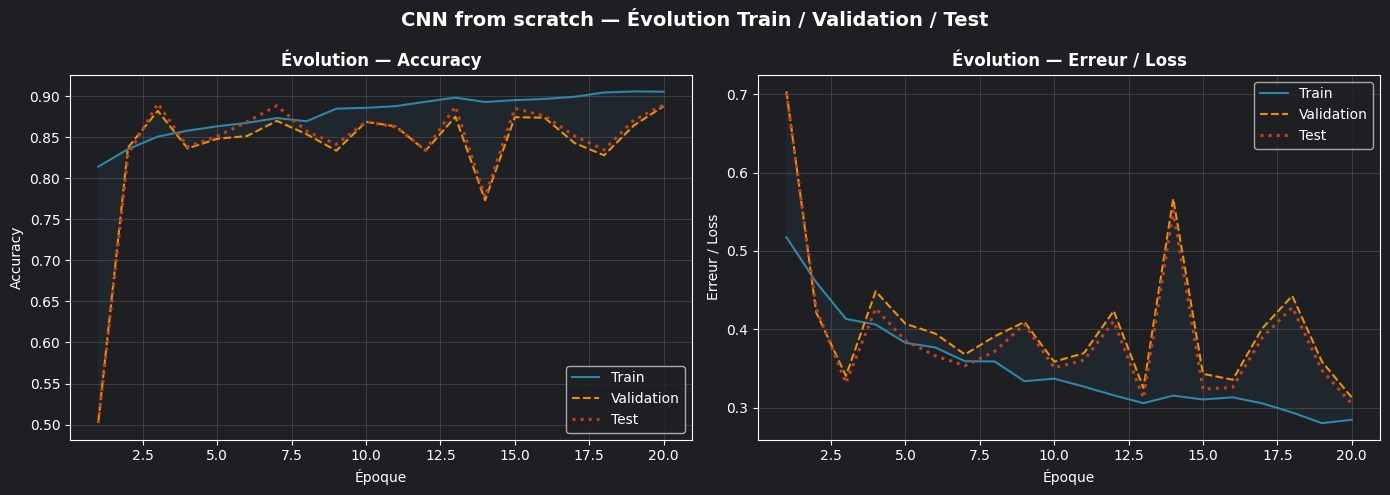

In [13]:
def plot_history(history, title, save_path=None, test_history=None):
    """Affiche les courbes accuracy et loss pour train, validation et test."""
    hist = history.history  # Dictionnaire {métrique: liste de valeurs par époque}
    ep   = range(1, len(hist['accuracy']) + 1)  # Axe X : numéros d'époques
    test_history = test_history or {}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Boucle sur les deux graphiques : Accuracy et Loss
    for ax, key, ylabel in zip(axes, ['accuracy', 'loss'], ['Accuracy', 'Erreur / Loss']):
        train_vals = hist[key]           # Courbe d'entraînement
        val_vals   = hist[f'val_{key}']  # Courbe de validation
        test_key   = f'test_{key}'
        test_vals  = test_history.get(test_key, hist.get(test_key))

        ax.plot(ep, train_vals, color='#2E86AB', label='Train')
        ax.plot(ep, val_vals, color='#F18F01', linestyle='--', label='Validation')

        if test_vals is not None and len(test_vals) == len(train_vals):
            ax.plot(ep, test_vals, color='#C73E1D', linestyle=':', linewidth=2.2, label='Test')

        # Zone colorée entre train et validation :
        # plus la zone est large, plus l'écart train/val est grand.
        ax.fill_between(ep, train_vals, val_vals, alpha=0.08, color='#2E86AB')

        ax.set_title(f'Evolution - {ylabel}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoque')
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()


# Affichage des courbes du CNN
# Le test set est évalué à chaque époque uniquement pour répondre au livrable :
# les décisions de training restent pilotées par train/validation.
plot_history(
    history_cnn,
    'CNN from scratch - Evolution Train / Validation / Test',
    FIGURES_DIR / 'curves_cnn.png',
    test_history=test_metrics_logger.history
)

---
## 6.1 Comparaison de deux modèles binaires

Pour valider la robustesse de l'approche binaire, on compare deux modèles CNN entraînés sur le même objectif Photo / Not_Photo.
On compare :

| Modèle | Rôle | Hypothèse |
|---|---|---|
| **CNN Scratch principal** | Modèle retenu pour le tri final | Plus expressif, meilleure capacité à gérer les cas difficiles |
| **CNN Light** | Baseline plus simple | Moins de paramètres, entraînement plus rapide, mais risque de sous-apprentissage |

Les deux modèles utilisent le même pipeline :

- mêmes images filtrées,
- même split train / validation / test,
- même conversion binaire Photo / Not_Photo,
- même loss `binary_crossentropy`,
- même optimizer `Adam(1e-4)`,
- mêmes métriques Keras.

La comparaison porte sur :

1. l'évolution train / validation / test de la loss et de l'accuracy,
2. les métriques finales sur le test set,
3. le compromis biais/variance.

Le modèle principal reste `model_cnn`, car il est plus adapté aux peintures réalistes, qui constituent
la principale difficulté du dataset.

Model: "CNN_Light"

+=================================+========================+===============+
| Layer (type)                    | Output Shape           |       Param # |
+=================================+========================+===============+
| augmentation (Sequential)       | (1, 224, 224, 3)       |             0 |
+---------------------------------+------------------------+---------------+
| rescaling_1 (Rescaling)         | (1, 224, 224, 3)       |             0 |
+---------------------------------+------------------------+---------------+
| conv2d_4 (Conv2D)               | (1, 224, 224, 16)      |           448 |
+---------------------------------+------------------------+---------------+
| batch_normalization_6           | (1, 224, 224, 16)      |            64 |
| (BatchNormalization)            |                        |               |
+---------------------------------+------------------------+---------------+
| max_pooling2d_4 (MaxPooling2D)  | (1, 112, 112, 16)      |             0 |
+---------------------------------+------------------------+---------------+
| conv2d_5 (Conv2D)               | (1, 112, 112, 32)      |         4,640 |
+---------------------------------+------------------------+---------------+
| batch_normalization_7           | (1, 112, 112, 32)      |           128 |
| (BatchNormalization)            |                        |               |
+---------------------------------+------------------------+---------------+
| max_pooling2d_5 (MaxPooling2D)  | (1, 56, 56, 32)        |             0 |
+---------------------------------+------------------------+---------------+
| conv2d_6 (Conv2D)               | (1, 56, 56, 64)        |        18,496 |
+---------------------------------+------------------------+---------------+
| batch_normalization_8           | (1, 56, 56, 64)        |           256 |
| (BatchNormalization)            |                        |               |
+---------------------------------+------------------------+---------------+
| max_pooling2d_6 (MaxPooling2D)  | (1, 28, 28, 64)        |             0 |
+---------------------------------+------------------------+---------------+
| global_average_pooling2d_1      | (1, 64)                |             0 |
| (GlobalAveragePooling2D)        |                        |               |
+---------------------------------+------------------------+---------------+
| dense_3 (Dense)                 | (1, 64)                |         4,160 |
+---------------------------------+------------------------+---------------+
| dropout_2 (Dropout)             | (1, 64)                |             0 |
+---------------------------------+------------------------+---------------+
| dense_4 (Dense)                 | (1, 1)                 |            65 |
+---------------------------------+------------------------+---------------+

 Total params: 28,257 (110.38 KB)

 Trainable params: 28,033 (109.50 KB)

 Non-trainable params: 224 (896.00 B)

 Entraînement du CNN Light...

Epoch 1/20
224/224 ==================== 0s 95ms/step - accuracy: 0.8162 - auc: 0.8584 - loss: 0.4270 - precision: 0.7646 - recall: 0.9128 - test_loss: 0.6328 - test_accuracy: 0.7373
224/224 ==================== 43s 154ms/step - accuracy: 0.8355 - auc: 0.8845 - loss: 0.3847 - precision: 0.7781 - recall: 0.9388 - val_accuracy: 0.7324 - val_auc: 0.7497 - val_loss: 0.6298 - val_precision: 0.6538 - val_recall: 0.9877 - learning_rate: 1.0000e-04 - test_loss: 0.6328 - test_accuracy: 0.7373
Epoch 2/20
224/224 ==================== 0s 96ms/step - accuracy: 0.8510 - auc: 0.9058 - loss: 0.3502 - precision: 0.7893 - recall: 0.9542 - test_loss: 0.4117 - test_accuracy: 0.8391
224/224 ==================== 35s 153ms/step - accuracy: 0.8483 - auc: 0.9057 - loss: 0.3518 - precision: 0.7922 - recall: 0.9444 - val_accuracy: 0.8419 - val_auc: 0.9072 - val_loss: 0.4061 - val_precision: 0.7881 - val_recall: 0.9352 - learning_rate: 1.0000e-04 - test_loss: 0.4117 - test_accuracy: 

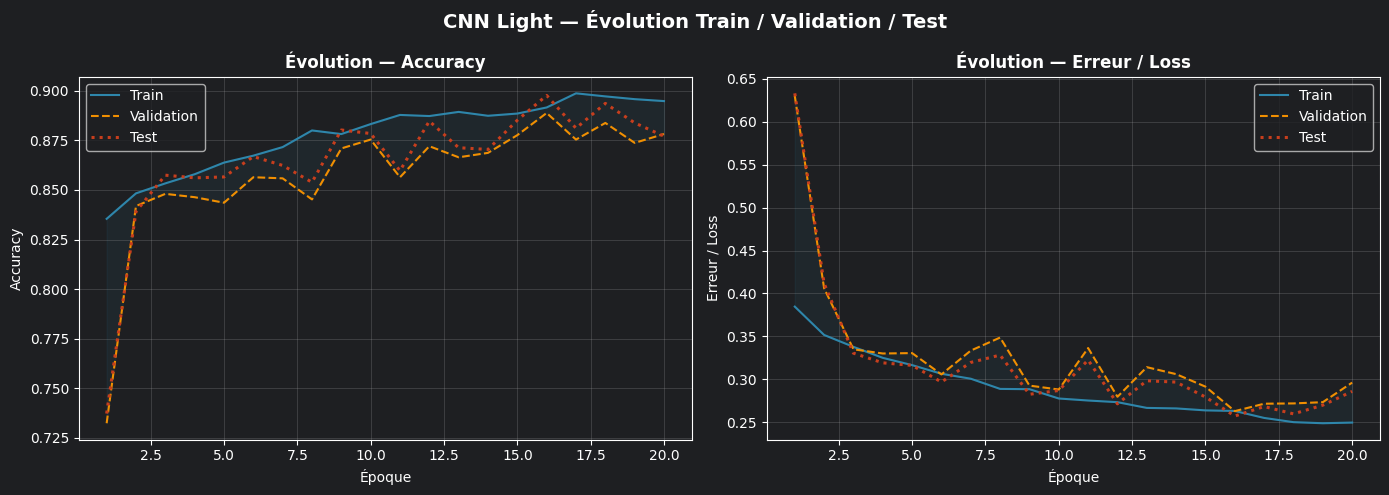

70/70 ==================== 6s 88ms/step - accuracy: 0.8977 - auc: 0.9594 - loss: 0.2574 - precision: 0.9031 - recall: 0.8910


,Modèle,Paramètres,Test loss,Test accuracy,Test AUC,Test precision,Test recall,Rôle
0,CNN Scratch principal,"432,321",0.3048,0.8892,0.9667,0.9325,0.8391,Modèle retenu
1,CNN Light baseline,"28,257",0.2574,0.8977,0.9594,0.9031,0.8910,Modèle de comparaison


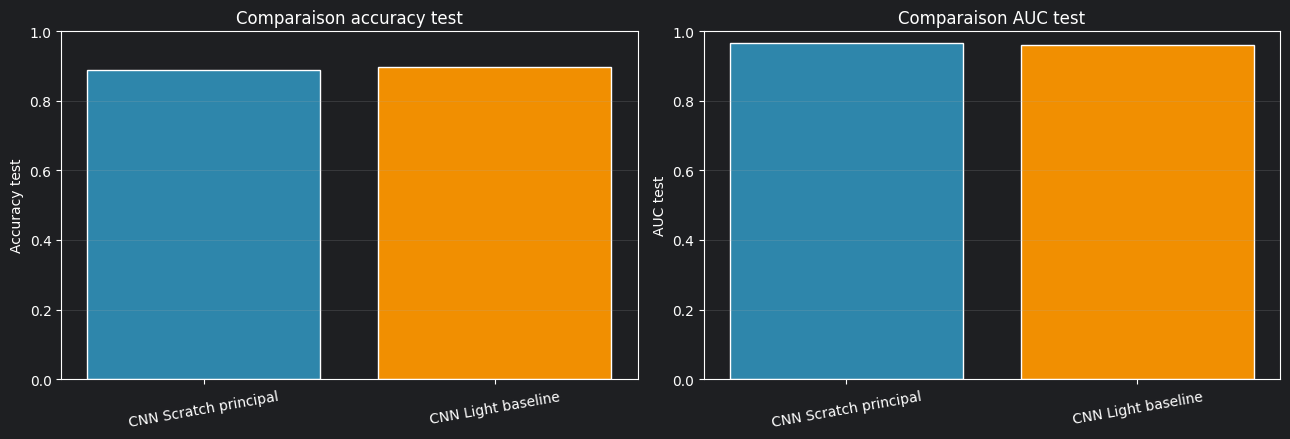

Conclusion comparaison :
- CNN Light sert de baseline plus simple.
- CNN Scratch principal est conservé pour l'évaluation détaillée et le tri final.
- Le choix final doit privilégier le meilleur compromis AUC / recall Photo / faux positifs Painting.


In [14]:
def build_cnn_light(input_shape=(IMAGE_H, IMAGE_W, 3)):
    """Baseline CNN plus léger pour comparer l'évolution avec le modèle principal."""
    model = Sequential(name='CNN_Light')
    model.add(data_augmentation)
    model.add(layers.Rescaling(1./255, input_shape=input_shape))

    for filters in [16, 32, 64]:
        model.add(Conv2D(filters, 3, padding='same', activation='relu'))
        model.add(BatchNormalization())
        model.add(MaxPooling2D(2))

    model.add(GlobalAveragePooling2D())
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model


model_light = build_cnn_light()
model_light.summary()

test_metrics_logger_light = TestMetricsLogger(test_bin)

print(" Entraînement du CNN Light...\n")
history_light = model_light.fit(
    train_bin,
    validation_data=val_bin,
    epochs=EPOCHS_CNN,
    callbacks=get_callbacks('cnn_light') + [test_metrics_logger_light],
    class_weight=class_weight,
    verbose=1
)

plot_history(
    history_light,
    'CNN Light - Evolution Train / Validation / Test',
    FIGURES_DIR / 'curves_cnn_light.png',
    test_history=test_metrics_logger_light.history
)

eval_light = model_light.evaluate(test_bin, verbose=1, return_dict=True)
eval_main_at_training_threshold = model_cnn.evaluate(test_bin, verbose=0, return_dict=True)

comparison_binary = pd.DataFrame([
    {
        'Modèle': 'CNN Scratch principal',
        'Paramètres': model_cnn.count_params(),
        'Test loss': eval_main_at_training_threshold['loss'],
        'Test accuracy': eval_main_at_training_threshold['accuracy'],
        'Test AUC': eval_main_at_training_threshold['auc'],
        'Test precision': eval_main_at_training_threshold['precision'],
        'Test recall': eval_main_at_training_threshold['recall'],
        'Rôle': 'Modèle retenu'
    },
    {
        'Modèle': 'CNN Light baseline',
        'Paramètres': model_light.count_params(),
        'Test loss': eval_light['loss'],
        'Test accuracy': eval_light['accuracy'],
        'Test AUC': eval_light['auc'],
        'Test precision': eval_light['precision'],
        'Test recall': eval_light['recall'],
        'Rôle': 'Modèle de comparaison'
    }
])

display(
    comparison_binary.style
        .format({
            'Paramètres': '{:,.0f}',
            'Test loss': '{:.4f}',
            'Test accuracy': '{:.4f}',
            'Test AUC': '{:.4f}',
            'Test precision': '{:.4f}',
            'Test recall': '{:.4f}',
        })
        .background_gradient(subset=['Test accuracy', 'Test AUC'], cmap='YlGnBu')
        .set_caption('Comparaison binaire : CNN principal vs CNN Light')
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(
    comparison_binary['Modèle'],
    comparison_binary['Test accuracy'],
    color=['#2E86AB', '#F18F01'],
    edgecolor='white'
)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Accuracy test')
axes[0].set_title('Comparaison accuracy test')
axes[0].tick_params(axis='x', rotation=10)
axes[0].grid(axis='y', alpha=0.25)

axes[1].bar(
    comparison_binary['Modèle'],
    comparison_binary['Test AUC'],
    color=['#2E86AB', '#F18F01'],
    edgecolor='white'
)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('AUC test')
axes[1].set_title('Comparaison AUC test')
axes[1].tick_params(axis='x', rotation=10)
axes[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'comparison_binary_models.png', dpi=100, bbox_inches='tight')
plt.show()

print("Conclusion comparaison :")
print("- CNN Light sert de baseline plus simple.")
print("- CNN Scratch principal est conservé pour l'évaluation détaillée et le tri final.")
print("- Le choix final doit privilégier le meilleur compromis AUC / recall Photo / faux positifs Painting.")

---
## 6.2 Classification multiclasse avec optimisation d'hyperparamètres

En complément de l'objectif principal binaire, une expérience multiclasse est menée sur les 5 catégories d'origine avec :

- un modèle,
- son évolution,
- une optimisation des hyperparamètres.

Ici, on revient aux 5 classes d'origine :

```text
Photo / Painting / Schematics / Sketch / Text
```

Cette tâche est différente de la classification binaire :

| Elément | Binaire | Multiclasse |
|---|---|---|
| Sortie | `Dense(1, sigmoid)` | `Dense(5, softmax)` |
| Loss | `binary_crossentropy` | `sparse_categorical_crossentropy` |
| Label | 0 ou 1 | entier de 0 à 4 |
| Objectif | Photo vs Not_Photo | retrouver la classe exacte |

Pour rester raisonnable en temps de calcul, l'optimisation est une **recherche manuelle ciblée**
sur quelques configurations. On compare :

- le nombre de filtres convolutifs,
- la taille de la couche dense,
- le dropout,
- le learning rate.

La meilleure configuration est choisie sur `val_accuracy`, puis évaluée sur le test set.


Essai multiclasse : small
Epoch 1/20
224/224 ==================== 48s 191ms/step - accuracy: 0.7156 - loss: 0.7869 - val_accuracy: 0.6363 - val_loss: 1.1536 - learning_rate: 1.0000e-04
Epoch 2/20
224/224 ==================== 41s 183ms/step - accuracy: 0.7864 - loss: 0.5897 - val_accuracy: 0.7447 - val_loss: 0.6895 - learning_rate: 1.0000e-04
Epoch 3/20
224/224 ==================== 41s 181ms/step - accuracy: 0.8095 - loss: 0.5211 - val_accuracy: 0.8162 - val_loss: 0.5370 - learning_rate: 1.0000e-04
Epoch 4/20
224/224 ==================== 41s 184ms/step - accuracy: 0.8219 - loss: 0.4857 - val_accuracy: 0.8022 - val_loss: 0.5298 - learning_rate: 1.0000e-04
Epoch 5/20
224/224 ==================== 41s 181ms/step - accuracy: 0.8362 - loss: 0.4486 - val_accuracy: 0.7156 - val_loss: 0.6821 - learning_rate: 1.0000e-04
Epoch 6/20
224/224 ==================== 41s 181ms/step - accuracy: 0.8430 - loss: 0.4313 - val_accuracy: 0.8229 - val_loss: 0.4902 - learning_rate: 1.0000e-04
Epoch 7/20
224/224 

,Configuration,Filtres,Dense units,Dropout,Learning rate,Paramètres,Best epoch,Best val_accuracy
0,small,"[32, 64, 128]",128,0.30,1e-04,"111,301",8,0.8609
1,regularized,"[32, 64, 128, 256]",128,0.50,5e-05,"423,877",6,0.8665



Meilleure configuration multiclasse :
{'name': 'regularized', 'filters': [32, 64, 128, 256], 'dense_units': 128, 'dropout': 0.5, 'learning_rate': 5e-05}


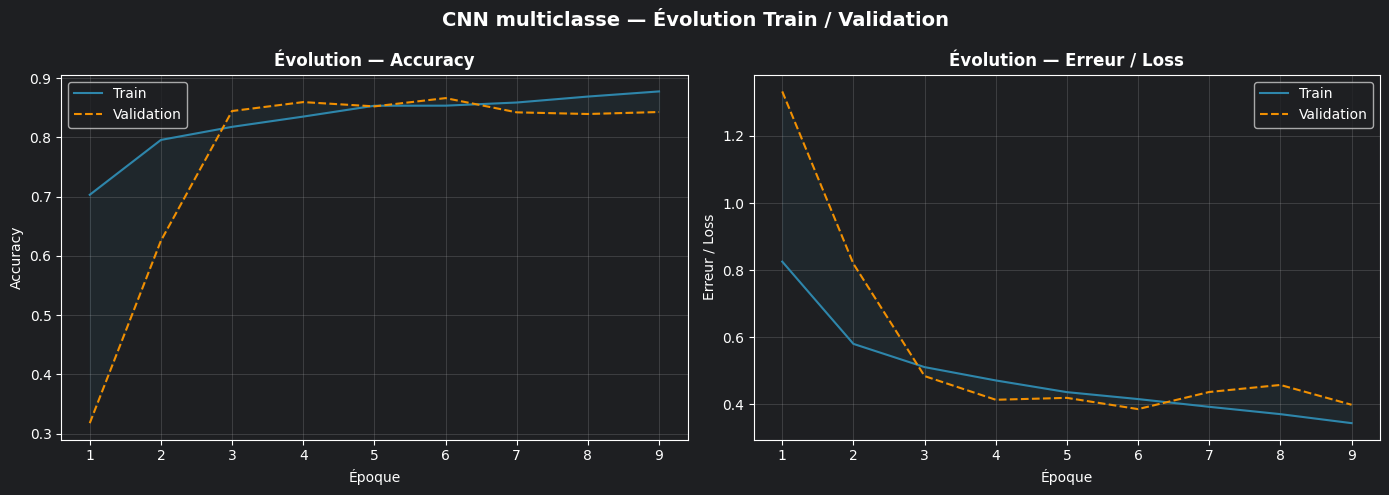

70/70 ==================== 10s 135ms/step - accuracy: 0.8615 - loss: 0.3781

Evaluation multiclasse sur test :
  accuracy  : 0.8615
  loss      : 0.3781

Rapport de classification multiclasse :
              precision    recall  f1-score   support

    Painting       0.68      0.47      0.56       277
       Photo       0.88      0.94      0.90      1119
  Schematics       0.85      0.72      0.78       280
      Sketch       0.87      0.98      0.92       281
        Text       0.93      0.97      0.95       281

    accuracy                           0.86      2238
   macro avg       0.84      0.82      0.82      2238
weighted avg       0.85      0.86      0.85      2238



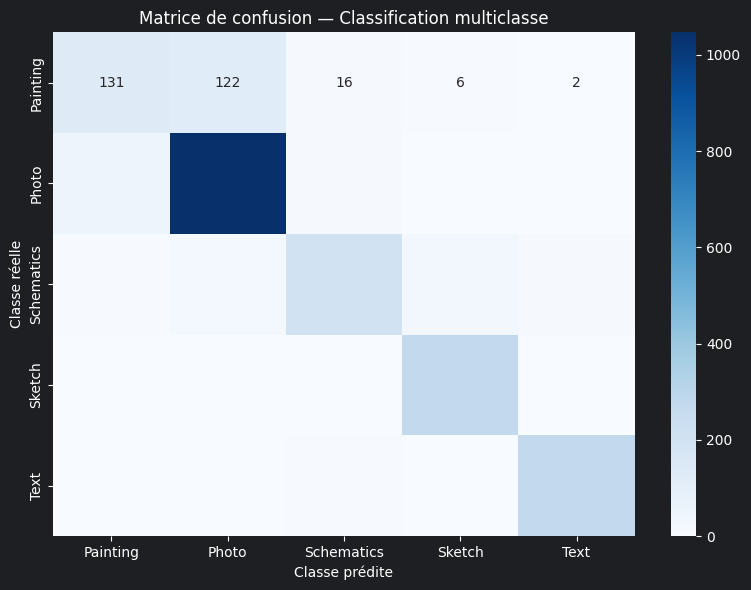

Conclusion multiclasse :
- La sortie softmax permet de prédire directement les 5 classes d'origine.
- La meilleure configuration est sélectionnée sur validation pour éviter d'optimiser sur le test.
- Cette section complète l'objectif multiclasse, tandis que le tri final reste basé sur Photo / Not_Photo.


In [15]:
def build_multiclass_cnn(config, input_shape=(IMAGE_H, IMAGE_W, 3), n_classes=None):
    """CNN multiclasse paramétrable pour une recherche simple d'hyperparamètres."""
    n_classes = n_classes or num_classes
    model = Sequential(name=f"Multiclass_CNN_{config['name']}")
    model.add(data_augmentation)
    model.add(layers.Rescaling(1./255, input_shape=input_shape))

    for filters in config['filters']:
        model.add(Conv2D(filters, 3, padding='same', activation='relu'))
        model.add(BatchNormalization())
        model.add(MaxPooling2D(2))

    model.add(GlobalAveragePooling2D())
    model.add(Dense(config['dense_units'], activation='relu'))
    model.add(Dropout(config['dropout']))
    model.add(Dense(n_classes, activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(config['learning_rate']),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )
    return model


multiclass_configs = [
    {
        'name': 'small',
        'filters': [32, 64, 128],
        'dense_units': 128,
        'dropout': 0.30,
        'learning_rate': 1e-4,
    },
    {
        'name': 'regularized',
        'filters': [32, 64, 128, 256],
        'dense_units': 128,
        'dropout': 0.50,
        'learning_rate': 5e-5,
    },
]

multiclass_trials = []

for config in multiclass_configs:
    print("\n" + "="*60)
    print(f"Essai multiclasse : {config['name']}")
    print("="*60)

    candidate = build_multiclass_cnn(config)
    history_candidate = candidate.fit(
        train_multi,
        validation_data=val_multi,
        epochs=EPOCHS_CNN,
        callbacks=get_callbacks(f"multiclass_{config['name']}", patience_stop=3, patience_lr=2),
        verbose=1
    )

    best_val_acc = float(max(history_candidate.history['val_accuracy']))
    best_epoch = int(np.argmax(history_candidate.history['val_accuracy']) + 1)

    multiclass_trials.append({
        'config': config,
        'model': candidate,
        'history': history_candidate,
        'best_val_accuracy': best_val_acc,
        'best_epoch': best_epoch,
        'parameters': candidate.count_params(),
    })

multiclass_search_df = pd.DataFrame([
    {
        'Configuration': trial['config']['name'],
        'Filtres': str(trial['config']['filters']),
        'Dense units': trial['config']['dense_units'],
        'Dropout': trial['config']['dropout'],
        'Learning rate': trial['config']['learning_rate'],
        'Paramètres': trial['parameters'],
        'Best epoch': trial['best_epoch'],
        'Best val_accuracy': trial['best_val_accuracy'],
    }
    for trial in multiclass_trials
])

display(
    multiclass_search_df.style
        .format({
            'Dropout': '{:.2f}',
            'Learning rate': '{:.0e}',
            'Paramètres': '{:,.0f}',
            'Best val_accuracy': '{:.4f}',
        })
        .background_gradient(subset=['Best val_accuracy'], cmap='YlGnBu')
        .set_caption('Recherche d hyperparamètres - classification multiclasse')
)

best_multiclass_trial = max(multiclass_trials, key=lambda item: item['best_val_accuracy'])
model_multiclass = best_multiclass_trial['model']
history_multiclass = best_multiclass_trial['history']

print("\nMeilleure configuration multiclasse :")
print(best_multiclass_trial['config'])

plot_history(
    history_multiclass,
    'CNN multiclasse - Evolution Train / Validation',
    FIGURES_DIR / 'curves_multiclass.png'
)

eval_multiclass = model_multiclass.evaluate(test_multi, verbose=1, return_dict=True)
print("\nEvaluation multiclasse sur test :")
for metric, value in eval_multiclass.items():
    print(f"  {metric:<10}: {value:.4f}")

y_true_multi = []
y_pred_multi = []

for images, labels in test_multi:
    probs = model_multiclass.predict(images, verbose=0)
    y_true_multi.extend(labels.numpy().tolist())
    y_pred_multi.extend(np.argmax(probs, axis=1).tolist())

print("\nRapport de classification multiclasse :")
print(classification_report(y_true_multi, y_pred_multi, target_names=class_names, zero_division=0))

cm_multi = confusion_matrix(y_true_multi, y_pred_multi)
fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    cm_multi,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"size": 11, "weight": "bold"},
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    ax=ax
)

# Make annotation text readable on both light and dark cells
threshold_color = cm_multi.max() / 2
for text in ax.texts:
    value = int(text.get_text())
    text.set_color("white" if value > threshold_color else "black")

ax.set_xlabel('Classe prédite')
ax.set_ylabel('Classe réelle')
ax.set_title('Matrice de confusion - Classification multiclasse')
ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.set_yticklabels(class_names, rotation=0)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eval_multiclass.png', dpi=120, bbox_inches='tight')
plt.show()

print("Conclusion multiclasse :")
print("- La sortie softmax permet de prédire directement les 5 classes d'origine.")
print("- La meilleure configuration est sélectionnée sur validation pour éviter d'optimiser sur le test.")
print("- Cette section complète l'objectif multiclasse, tandis que le tri final reste basé sur Photo / Not_Photo.")

---
## 7. Evaluation détaillée

### Protocole d'évaluation en deux étapes

L'évaluation en deux temps est une bonne pratique pour éviter le **biais d'optimisme** :

```
+------------------------------------------------------------------+
| ETAPE 1 - model.evaluate()  (section 7.1)                        |
|                                                                  |
|   Métriques officielles Keras sur test_bin                       |
|   Accuracy / AUC / Precision / Recall / F1                       |
|   -> Rapide, reproductible, fidèle au pipeline d'entraînement     |
+------------------------------------------------------------------+
              |
              v
+------------------------------------------------------------------+
| ETAPE 2 - full_evaluation()  (section 7.2)                       |
|                                                                  |
|   ① Matrice de confusion    -> types d'erreurs (TP/FP/TN/FN)      |
|   ② Courbe ROC + AUC        -> discrimination indépendante du seuil|
|   ③ Seuil Youden J          -> seuil optimal sur val_bin          |
|   ④ Diagnostic biais/var    -> gap train_acc vs test_acc           |
+------------------------------------------------------------------+
```

### Pourquoi ces métriques plutôt que l'accuracy seule ?

| Métrique | Formule | Avantage | Limite |
|---|---|---|---|
| **Accuracy** | $\frac{TP+TN}{TP+TN+FP+FN}$ | Facile à interpréter | Trompeuse si dataset déséquilibré |
| **Precision** | $\frac{TP}{TP+FP}$ | Mesure la fiabilité des prédictions positives | Ignore les faux négatifs |
| **Recall** | $\frac{TP}{TP+FN}$ | Mesure la capacité à retrouver les photos | Ignore les faux positifs |
| **F1-score** | $\frac{2PR}{P+R}$ | Compromis Precision/Recall | Ne reflète pas les vrais négatifs |
| **AUC-ROC** | $\int_0^1 TPR(FPR)\,dFPR$ | Indépendante du seuil, robuste au déséquilibre | Moins intuitive |

> **Règle d'or pour ce projet** : un Recall élevé (> 0.85) sur Photo est prioritaire -
> il vaut mieux inclure quelques non-photos (faux positifs) que rater des vraies photos.

### 7.1 Evaluation Keras standard - `model.evaluate()`

`model.evaluate()` calcule exactement les métriques déclarées dans `model.compile()`
sur un dataset donné, **sans recalculer les prédictions manuellement**.

#### Avantages de `model.evaluate()`

- **Identique à l'entraînement** : utilise le même pipeline de données et les mêmes métriques
- **Pas de biais de seuil** : les métriques AUC, Precision, Recall sont calculées sur l'ensemble du test,
  pas sur un sous-ensemble
- **Léger en mémoire** : les prédictions ne sont pas stockées (calcul en streaming)

#### Calcul du F1-score

Le F1 n'est pas une métrique native `model.compile()` dans TF 2.x.
Il est dérivé a posteriori à partir de Precision et Recall :

$$
F_1 = \frac{2 \times Precision \times Recall}{Precision + Recall}
$$

Cette formule est la **moyenne harmonique** de P et R :
elle pénalise fortement les cas où l'un des deux est très bas.

280/280 ==================== 8s 26ms/step - accuracy: 0.8892 - auc: 0.9667 - loss: 0.3048 - precision: 0.9325 - recall: 0.8391
Evaluation Keras sur le jeu de test


,Metrique,Valeur,Lecture
0,Accuracy,0.8892,Plus haut = mieux
1,AUC-ROC,0.9667,Plus haut = mieux
2,Loss,0.3048,Plus bas = mieux
3,Precision,0.9325,Plus haut = mieux
4,Recall,0.8391,Plus haut = mieux
5,F1-score,0.8833,Plus haut = mieux


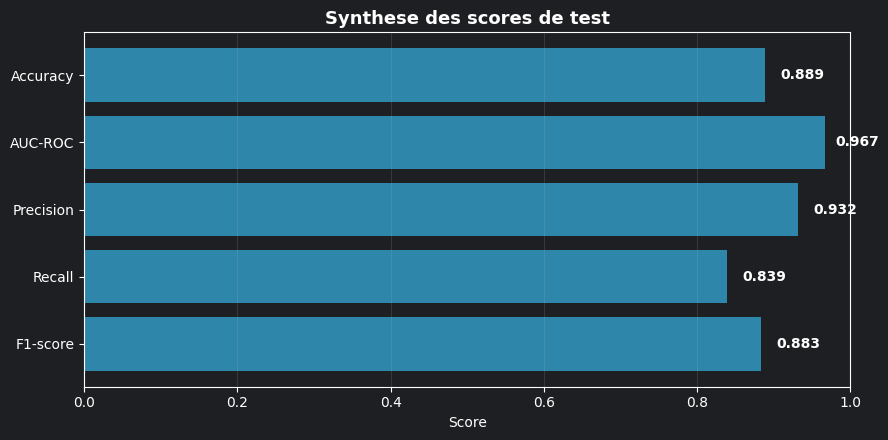


Comment lire ces resultats :
- Accuracy : proportion totale de bonnes predictions.
- AUC-ROC  : capacite du modele a separer Photo et Not_Photo, independamment du seuil.
- Precision: parmi les images predites Photo, proportion vraiment Photo.
- Recall   : parmi les vraies Photo, proportion retrouvee par le modele.
- F1-score : compromis entre precision et recall.


In [16]:
# Evaluation Keras standard sur le jeu de test.
# On cree l'alias `model` pour montrer explicitement l'appel Keras classique : model.evaluate(...).
model = model_cnn

# Dataset complet de test, sans cache ni prefetch agressif pour eviter un crash kernel.
# On repart des chemins de test pour eviter le prefetch(AUTOTUNE) deja present dans test_multi.
test_bin_eval = (
    tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
    .map(load_image, num_parallel_calls=1)
    .batch(8)
    .map(to_binary, num_parallel_calls=1)
    .prefetch(1)
)

eval_results = model.evaluate(test_bin_eval, verbose=1, return_dict=True)

# F1 n'est pas dans model.compile(), on le deduit de precision et recall.
precision_eval = eval_results.get('precision', np.nan)
recall_eval = eval_results.get('recall', np.nan)
f1_eval = (
    2 * precision_eval * recall_eval / (precision_eval + recall_eval)
    if (precision_eval + recall_eval) > 0 else 0.0
)

pretty_names = {
    'loss': 'Loss',
    'accuracy': 'Accuracy',
    'auc': 'AUC-ROC',
    'precision': 'Precision',
    'recall': 'Recall'
}

eval_table = pd.DataFrame([
    {
        'Metrique': pretty_names.get(metric, metric),
        'Valeur': value,
        'Lecture': 'Plus bas = mieux' if metric == 'loss' else 'Plus haut = mieux'
    }
    for metric, value in eval_results.items()
])
eval_table = pd.concat([
    eval_table,
    pd.DataFrame([{'Metrique': 'F1-score', 'Valeur': f1_eval, 'Lecture': 'Plus haut = mieux'}])
], ignore_index=True)

print('Evaluation Keras sur le jeu de test')
display(
    eval_table.style
        .format({'Valeur': '{:.4f}'})
        .background_gradient(subset=['Valeur'], cmap='YlGnBu')
        .set_caption('Resultats de model.evaluate(test_bin_eval)')
)

plot_data = eval_table[eval_table['Metrique'] != 'Loss'].copy()
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(plot_data['Metrique'], plot_data['Valeur'], color='#2E86AB')
ax.set_xlim(0, 1)
ax.set_xlabel('Score')
ax.set_title('Synthese des scores de test', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.25)
ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax.text(min(width + 0.02, 0.98), bar.get_y() + bar.get_height()/2,
            f'{width:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nComment lire ces resultats :')
print('- Accuracy : proportion totale de bonnes predictions.')
print('- AUC-ROC  : capacite du modele a separer Photo et Not_Photo, independamment du seuil.')
print('- Precision: parmi les images predites Photo, proportion vraiment Photo.')
print('- Recall   : parmi les vraies Photo, proportion retrouvee par le modele.')
print('- F1-score : compromis entre precision et recall.')

Seuil optimal (Youden J) : 0.350

 EVALUATION - CNN Scratch  (seuil=0.35)

Metriques sur test :
  Accuracy        : 0.9084
  AUC-ROC         : 0.9709
  Precision       : 0.8703
  Recall          : 0.9598
  F1-score        : 0.9129

Rapport de classification :
              precision    recall  f1-score   support

   Not_Photo       0.96      0.86      0.90      1119
       Photo       0.87      0.96      0.91      1119

    accuracy                           0.91      2238
   macro avg       0.91      0.91      0.91      2238
weighted avg       0.91      0.91      0.91      2238



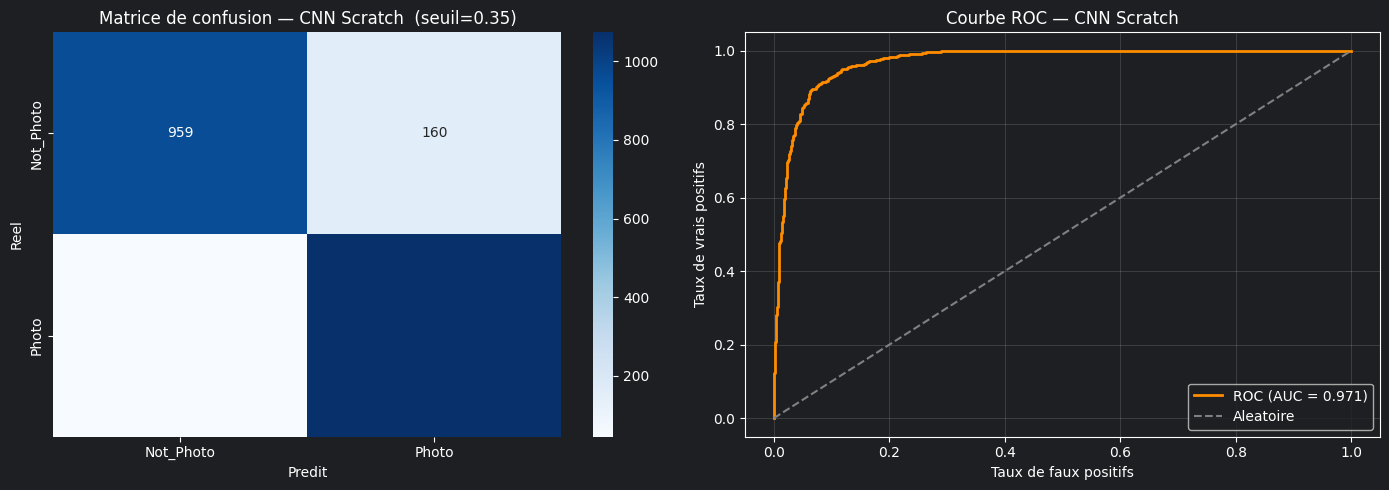


Analyse biais / variance :
  Train accuracy : 0.9262
  Test          : 0.9084
  Ecart          : 0.0178  (1.8%)
  Bon equilibre biais/variance


In [17]:
from sklearn.metrics import f1_score
from PIL import Image
import time, gc

DEBUG_EVAL = False
DEBUG_EVERY_BATCH = 25
EVAL_BATCH_SIZE = 16
FORCE_CPU_EVAL = False

def current_ram_mb():
    """RAM courante du kernel Jupyter sous Linux/WSL."""
    try:
        with open('/proc/self/status', 'r') as f:
            for line in f:
                if line.startswith('VmRSS:'):
                    return int(line.split()[1]) / 1024
    except Exception:
        return float('nan')
    return float('nan')

def debug_print(message):
    if DEBUG_EVAL:
        print(message, flush=True)

debug_print(f"[DEBUG] GPUs visibles par TensorFlow : {tf.config.list_physical_devices('GPU')}")
debug_print(f"[DEBUG] FORCE_CPU_EVAL={FORCE_CPU_EVAL}")

def predict_batch(model, images, set_name, batch_idx):
    device = '/CPU:0' if FORCE_CPU_EVAL else None
    debug_print(f"[DEBUG] {set_name} batch {batch_idx} predict device={device or 'default'}")
    if FORCE_CPU_EVAL:
        with tf.device('/CPU:0'):
            return model(tf.convert_to_tensor(images), training=False).numpy().flatten()
    return model(tf.convert_to_tensor(images), training=False).numpy().flatten()

def make_binary_eval_dataset(paths, labels, batch_size=EVAL_BATCH_SIZE):
    """Conteneur simple paths/labels : pas de tf.data, pas de cache, pas de prefetch."""
    return {
        'paths': np.asarray(paths),
        'labels': np.asarray(labels),
        'batch_size': int(batch_size),
    }

def iter_manual_batches(dataset, set_name):
    paths = dataset['paths']
    labels = dataset['labels']
    batch_size = dataset['batch_size']
    total = len(paths)
    total_batches = int(np.ceil(total / batch_size))
    for batch_idx, start_idx in enumerate(range(0, total, batch_size), start=1):
        end_idx = min(start_idx + batch_size, total)
        batch_paths = paths[start_idx:end_idx]
        batch_labels = labels[start_idx:end_idx]
        debug_print(
            f"[DEBUG] {set_name} batch {batch_idx}/{total_batches} LOAD START "
            f"| rows={start_idx}:{end_idx} | RAM={current_ram_mb():.1f} MB"
        )
        images = []
        for local_idx, path in enumerate(batch_paths, start=1):
            debug_print(f"[DEBUG] {set_name} batch {batch_idx} image {local_idx}/{len(batch_paths)} | {path}")
            with Image.open(str(path)) as img:
                img = img.convert('RGB').resize((IMAGE_W, IMAGE_H))
                images.append(np.asarray(img, dtype=np.float32))
        images = np.stack(images, axis=0)
        labels_bin = (batch_labels == photo_idx).astype(np.int32)
        debug_print(
            f"[DEBUG] {set_name} batch {batch_idx}/{total_batches} LOAD DONE "
            f"| shape={images.shape} | RAM={current_ram_mb():.1f} MB"
        )
        yield batch_idx, total_batches, images, labels_bin

def full_evaluation(model, eval_dataset, train_dataset, model_name, dataset_name='Test', threshold=THRESHOLD):
    """Evaluation complete sur un dataset final : metriques, matrice de confusion, courbe ROC, biais/variance."""
    print(f"\n{'='*60}")
    print(f" EVALUATION - {model_name}  (seuil={threshold:.2f})")
    print(f"{'='*60}")

    def collect_preds(dataset, set_name):
        start = time.time()
        total_batches = int(np.ceil(len(dataset['paths']) / dataset['batch_size']))
        total_txt = total_batches
        debug_print(f"\n[DEBUG] Debut collecte {set_name} | batches={total_txt} | RAM={current_ram_mb():.1f} MB")
        y_true, y_prob = [], []
        for batch_idx, total_batches, images, labels in iter_manual_batches(dataset, set_name):
            batch_start = time.time()
            debug_print(
                f"[DEBUG] {set_name} batch {batch_idx}/{total_batches} INFER START "
                f"| shape={tuple(images.shape)} | RAM={current_ram_mb():.1f} MB"
            )
            probs = predict_batch(model, images, set_name, batch_idx)
            y_prob.extend(probs.tolist())
            y_true.extend(labels.tolist())
            if batch_idx % DEBUG_EVERY_BATCH == 0:
                debug_print(
                    f"[DEBUG] {set_name} batch {batch_idx}/{total_batches} INFER DONE "
                    f"| n={len(y_true)} | batch_time={time.time()-batch_start:.2f}s "
                    f"| elapsed={time.time()-start:.1f}s | RAM={current_ram_mb():.1f} MB"
                )
            del images, labels, probs
            if batch_idx % 25 == 0:
                gc.collect()
                debug_print(f"[DEBUG] {set_name} gc.collect() | RAM={current_ram_mb():.1f} MB")
        debug_print(f"[DEBUG] Fin collecte {set_name} | n={len(y_true)} | elapsed={time.time()-start:.1f}s | RAM={current_ram_mb():.1f} MB")
        return np.array(y_true), np.array(y_prob)

    def collect_accuracy(dataset, set_name, threshold):
        start = time.time()
        total_batches = int(np.ceil(len(dataset['paths']) / dataset['batch_size']))
        total_txt = total_batches
        debug_print(f"\n[DEBUG] Debut accuracy {set_name} | batches={total_txt} | RAM={current_ram_mb():.1f} MB")
        total_seen = 0
        total_correct = 0
        for batch_idx, total_batches, images, labels in iter_manual_batches(dataset, set_name):
            batch_start = time.time()
            debug_print(
                f"[DEBUG] {set_name} accuracy batch {batch_idx}/{total_batches} INFER START "
                f"| shape={tuple(images.shape)} | RAM={current_ram_mb():.1f} MB"
            )
            probs = predict_batch(model, images, set_name, batch_idx)
            labels_np = labels.astype(int).flatten()
            preds = (probs >= threshold).astype(int)
            total_correct += int(np.sum(preds == labels_np))
            total_seen += int(labels_np.size)
            debug_print(
                f"[DEBUG] {set_name} accuracy batch {batch_idx}/{total_batches} INFER DONE "
                f"| n={total_seen} | acc_so_far={total_correct/max(total_seen, 1):.4f} "
                f"| batch_time={time.time()-batch_start:.2f}s | elapsed={time.time()-start:.1f}s "
                f"| RAM={current_ram_mb():.1f} MB"
            )
            del images, labels, probs, labels_np, preds
            if batch_idx % 25 == 0:
                gc.collect()
                debug_print(f"[DEBUG] {set_name} accuracy gc.collect() | RAM={current_ram_mb():.1f} MB")
        acc = total_correct / max(total_seen, 1)
        debug_print(f"[DEBUG] Fin accuracy {set_name} | n={total_seen} | acc={acc:.4f} | elapsed={time.time()-start:.1f}s | RAM={current_ram_mb():.1f} MB")
        return float(acc)

    y_true,  y_pred_prob  = collect_preds(eval_dataset, dataset_name)
    gc.collect()
    debug_print(f"[DEBUG] Apres collecte {dataset_name} | RAM={current_ram_mb():.1f} MB")
    train_acc = collect_accuracy(train_dataset, 'Train', threshold)
    gc.collect()
    debug_print(f"[DEBUG] Apres accuracy Train | RAM={current_ram_mb():.1f} MB")

    y_pred       = (y_pred_prob  >= threshold).astype(int)

    eval_acc  = float(np.mean(y_pred       == y_true))
    gap       = train_acc - eval_acc
    auc       = roc_auc_score(y_true, y_pred_prob)

    from sklearn.metrics import precision_score, recall_score
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)

    print(f"\nMetriques sur {dataset_name.lower()} :")
    print(f"  {'Accuracy':<15} : {eval_acc:.4f}")
    print(f"  {'AUC-ROC':<15} : {auc:.4f}")
    print(f"  {'Precision':<15} : {precision:.4f}")
    print(f"  {'Recall':<15} : {recall:.4f}")
    print(f"  {'F1-score':<15} : {f1_score(y_true, y_pred, zero_division=0):.4f}")

    print("\nRapport de classification :")
    print(classification_report(y_true, y_pred, target_names=['Not_Photo', 'Photo']))

    cm = confusion_matrix(y_true, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Not_Photo', 'Photo'],
        yticklabels=['Not_Photo', 'Photo'],
        annot_kws={"size": 12, "weight": "bold"},
        linewidths=0.5,
        linecolor="white",
        cbar=True,
        ax=axes[0]
    )

    # Make annotation text readable on both light and dark cells
    threshold_color = cm.max() / 2
    for text in axes[0].texts:
        value = int(text.get_text())
        text.set_color("white" if value > threshold_color else "black")

    axes[0].set_xlabel('Prédit')
    axes[0].set_ylabel('Réel')
    axes[0].set_title(f'Matrice de confusion - {model_name}  (seuil={threshold:.2f})')

    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc:.3f})')
    axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Aleatoire')
    axes[1].set_xlabel('Taux de faux positifs')
    axes[1].set_ylabel('Taux de vrais positifs')
    axes[1].set_title(f'Courbe ROC - {model_name}')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'eval_{model_name.lower().replace(" ", "_")}.png',
                dpi=100, bbox_inches='tight')
    plt.show()

    print("\nAnalyse biais / variance :")
    print(f"  Train accuracy : {train_acc:.4f}")
    print(f"  {dataset_name:<14}: {eval_acc:.4f}")
    print(f"  Ecart          : {gap:.4f}  ({gap*100:.1f}%)")
    if eval_acc < 0.70:
        print("  Sous-apprentissage - augmenter la capacite du modele")
    elif gap > 0.15:
        print("  Sur-apprentissage - renforcer Dropout / augmentation")
    elif gap > 0.08:
        print("  Legere variance - acceptable")
    else:
        print("  Bon equilibre biais/variance")

    return {
        'model_name' : model_name,
        'dataset_name': dataset_name,
        'test_acc'   : eval_acc,
        'train_acc'  : train_acc,
        'gap'        : gap,
        'auc'        : auc,
        'precision'  : precision,
        'recall'     : recall,
        'f1'         : f1_score(y_true, y_pred, zero_division=0),
        'threshold'  : threshold,
        'y_true'     : y_true,
        'y_pred_prob': y_pred_prob,
    }



# -- Calcul du seuil optimal par courbe ROC ------------------------------------
# On collecte les probabilites sur le val set pour choisir le seuil.
# Le test set reste reserve a l'evaluation finale ci-dessous.
def _collect_probs(model, dataset, set_name):
    start = time.time()
    total_batches = int(np.ceil(len(dataset['paths']) / dataset['batch_size']))
    total_txt = total_batches
    debug_print(f"\n[DEBUG] Debut collecte {set_name} | batches={total_txt} | RAM={current_ram_mb():.1f} MB")
    y_true, y_prob = [], []
    for batch_idx, total_batches, images, labels in iter_manual_batches(dataset, set_name):
        batch_start = time.time()
        debug_print(
            f"[DEBUG] {set_name} batch {batch_idx}/{total_batches} INFER START "
            f"| shape={tuple(images.shape)} | RAM={current_ram_mb():.1f} MB"
        )
        probs = predict_batch(model, images, set_name, batch_idx)
        y_prob.extend(probs.tolist())
        y_true.extend(labels.tolist())
        if batch_idx % DEBUG_EVERY_BATCH == 0:
            debug_print(
                f"[DEBUG] {set_name} batch {batch_idx}/{total_batches} INFER DONE "
                f"| n={len(y_true)} | batch_time={time.time()-batch_start:.2f}s "
                f"| elapsed={time.time()-start:.1f}s | RAM={current_ram_mb():.1f} MB"
            )
        del images, labels, probs
        if batch_idx % 25 == 0:
            gc.collect()
            debug_print(f"[DEBUG] {set_name} gc.collect() | RAM={current_ram_mb():.1f} MB")
    debug_print(f"[DEBUG] Fin collecte {set_name} | n={len(y_true)} | elapsed={time.time()-start:.1f}s | RAM={current_ram_mb():.1f} MB")
    return np.array(y_true), np.array(y_prob)

val_bin_eval = make_binary_eval_dataset(val_paths, val_labels)
test_bin_eval = make_binary_eval_dataset(test_paths, test_labels)
train_bin_eval = make_binary_eval_dataset(train_paths, train_labels)

debug_print(
    f"[DEBUG] Datasets eval crees | batch_size={EVAL_BATCH_SIZE} "
    f"| val={len(val_paths)} images | test={len(test_paths)} images | train={len(train_paths)} images "
    f"| RAM={current_ram_mb():.1f} MB"
)

_y_true_val, _y_pred_prob_val = _collect_probs(model_cnn, val_bin_eval, 'Validation')
_fpr, _tpr, _thresholds = roc_curve(_y_true_val, _y_pred_prob_val)
_youden_j  = _tpr - _fpr
_best_idx  = int(np.argmax(_youden_j))
THRESHOLD  = float(_thresholds[_best_idx])
print(f'Seuil optimal (Youden J) : {THRESHOLD:.3f}')
del _y_true_val, _y_pred_prob_val, _fpr, _tpr, _thresholds, _youden_j
gc.collect()
debug_print(f"[DEBUG] Apres calcul seuil | RAM={current_ram_mb():.1f} MB")

results_cnn = full_evaluation(model_cnn, test_bin_eval, train_bin_eval, 'CNN Scratch', dataset_name='Test', threshold=THRESHOLD)


---
## 8. Tri automatique des images -> `data/processed/`

Le modèle CNN classe **toutes** les images du dataset brut et les copie dans :
- `data/processed/Photo/` - images reconnues comme photographies réelles
- `data/processed/Not_Photo/` - reste (peintures, schémas, croquis, textes)

### Schéma du processus de tri

```
data/raw/
  +-- Photo/        --+
  +-- Painting/     --+   CNN predict(batch)   -->  P(Photo) >= THRESHOLD ?
  +-- Schematics/   --+                              |              |
  +-- Sketch/       --+                            OUI             NON
  +-- Text/                                         |               |
                                                    v               v
                                             Photo/           Not_Photo/
                                           (original_class__filename.jpg)
```

### Décisions de conception

| Décision | Alternative écartée | Justification |
|---|---|---|
| **Copier** (`shutil.copy2`) | Déplacer (`shutil.move`) | Préserve le dataset brut - permet de retrier avec un seuil différent |
| **Préfixer le nom** (`Painting__img.jpg`) | Garder le nom original | Traçabilité : on voit immédiatement la classe d'origine dans le dossier |
| **Traitement par batch de 32** | Image par image | Utilise efficacement le GPU - ~32x plus rapide |
| **Gestion des doublons** (suffixe `_1`, `_2`) | Ecraser | Evite de perdre des images si deux classes ont des fichiers au même nom |

### Export CSV de traçabilité

Chaque prédiction est enregistrée dans `classification_report.csv` avec :
- `file` : nom du fichier source
- `original_class` : classe d'origine dans le dataset brut
- `predicted` : décision du modèle (Photo / Not_Photo)
- `probability` : $P(\text{Photo}\mid x)$ arrondie à 4 décimales - permet d'identifier les cas limites

Ce fichier permet un **audit manuel** des erreurs sans avoir à relancer le modèle.

In [18]:
def classify_and_sort_images(
    model, data_path, output_path,
    image_size=(IMAGE_H, IMAGE_W),
    threshold=THRESHOLD,
    batch_size=32
):
    """
    Prédit la classe de chaque image et copie vers Photo/ ou Not_Photo/.
    Retourne un dict résumé avec les détails de prédiction.
    """
    # Création des dossiers de destination s'ils n'existent pas
    dest_photo     = output_path / 'Photo'
    dest_not_photo = output_path / 'Not_Photo'
    dest_photo.mkdir(parents=True, exist_ok=True)
    dest_not_photo.mkdir(parents=True, exist_ok=True)

    EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

    # Dictionnaire résumé : compteurs et liste des prédictions individuelles
    summary = {'Photo': 0, 'Not_Photo': 0, 'errors': 0, 'details': []}

    # Collecte de toutes les images à traiter, avec leur classe d'origine
    # (ex: ('data/raw/Painting/img1.jpg', 'Painting'))
    all_images = [
        (f, folder.name)
        for folder in sorted(data_path.iterdir()) if folder.is_dir()
        for f in sorted(folder.iterdir()) if f.suffix.lower() in EXTENSIONS
    ]
    total = len(all_images)
    print(f"\n Traitement de {total} images...\n")

    # --- Traitement par batch ---
    # On regroupe les images en lots pour utiliser efficacement le GPU
    # (prédire image par image serait très lent)
    for batch_start in range(0, total, batch_size):
        batch        = all_images[batch_start:batch_start + batch_size]
        imgs_tensors = []  # Tenseurs des images correctement lues
        valid_batch  = []  # Métadonnées correspondantes (chemin + classe origine)

        # Lecture et redimensionnement de chaque image du batch
        for img_path, original_class in batch:
            try:
                raw = tf.io.read_file(str(img_path))
                # decode_image accepte JPG, PNG, BMP, GIF (expand_animations=False : ignore les GIFs)
                img = tf.io.decode_image(raw, channels=3, expand_animations=False)
                # Redimensionne à la taille attendue par le modèle (IMAGE_H x IMAGE_W)
                img = tf.image.resize(img, image_size)
                imgs_tensors.append(img)
                valid_batch.append((img_path, original_class))
            except Exception as e:
                # En cas d'image illisible, on l'ignore et on continue
                summary['errors'] += 1
                print(f"    Erreur lecture {img_path.name}: {e}")

        if not imgs_tensors:
            continue  # Batch entier invalide -> passer au suivant

        # Empile les tenseurs en un seul batch (forme : [batch, H, W, 3])
        # puis lance la prédiction en une seule passe -> efficace sur GPU
        probs = model.predict(tf.stack(imgs_tensors), verbose=0).flatten()

        # --- Application du seuil et copie vers le bon dossier ---
        for (img_path, original_class), prob in zip(valid_batch, probs):
            is_photo   = prob >= threshold  # True si photo, False sinon
            dest_class = 'Photo' if is_photo else 'Not_Photo'
            dest_dir   = dest_photo if is_photo else dest_not_photo

            # On préfixe le nom avec la classe d'origine pour la traçabilité
            # ex: "Painting__img001.jpg" -> permet de retrouver l'erreur plus tard
            new_name  = f"{original_class}__{img_path.name}"
            dest_file = dest_dir / new_name

            # Gestion des doublons de noms (si deux images différentes ont le même nom)
            counter = 1
            while dest_file.exists():
                dest_file = dest_dir / f"{original_class}__{img_path.stem}_{counter}{img_path.suffix}"
                counter += 1

            # shutil.copy2 copie le fichier en préservant les métadonnées (date, etc.)
            # On copie (et non déplace) pour ne pas modifier les données brutes originales
            shutil.copy2(str(img_path), str(dest_file))
            summary[dest_class] += 1

            # Enregistrement des détails de chaque prédiction pour export CSV
            summary['details'].append({
                'file'          : img_path.name,
                'original_class': original_class,
                'predicted'     : dest_class,
                'probability'   : round(float(prob), 4)  # Probabilité d'être une Photo
            })

        # Affichage de la progression en temps réel (end = écrase la ligne précédente)
        done = min(batch_start + batch_size, total)
        print(f"  [{done:>{len(str(total))}}/{total}]  "
              f"Photo: {summary['Photo']}  /  Not_Photo: {summary['Not_Photo']}",
              end='\r')

    print(f"\n\n{'='*55}")
    print("  TRI TERMINE")
    print(f"{'='*55}")
    print(f"   Photo     : {summary['Photo']} images -> {dest_photo}")
    print(f"   Not_Photo : {summary['Not_Photo']} images -> {dest_not_photo}")
    if summary['errors']:
        print(f"    Erreurs   : {summary['errors']} images ignorées")
    ratio = summary['Photo'] / max(summary['Photo'] + summary['Not_Photo'], 1)
    print(f"\n  Ratio Photo : {ratio:.1%} des images totales")
    return summary


# --- Lancement du tri ---
sort_summary = classify_and_sort_images(
    model      = model_cnn,
    data_path  = DATA_RAW,
    output_path= DATA_PROC,
    threshold  = THRESHOLD
)


 Traitement de 11247 images...

  [11247/11247]  Photo: 5594  /  Not_Photo: 5653

  TRI TERMINE
   Photo     : 5594 images -> /home/aymen/DS/Leyenda/data/processed/Photo
   Not_Photo : 5653 images -> /home/aymen/DS/Leyenda/data/processed/Not_Photo

  Ratio Photo : 49.7% des images totales


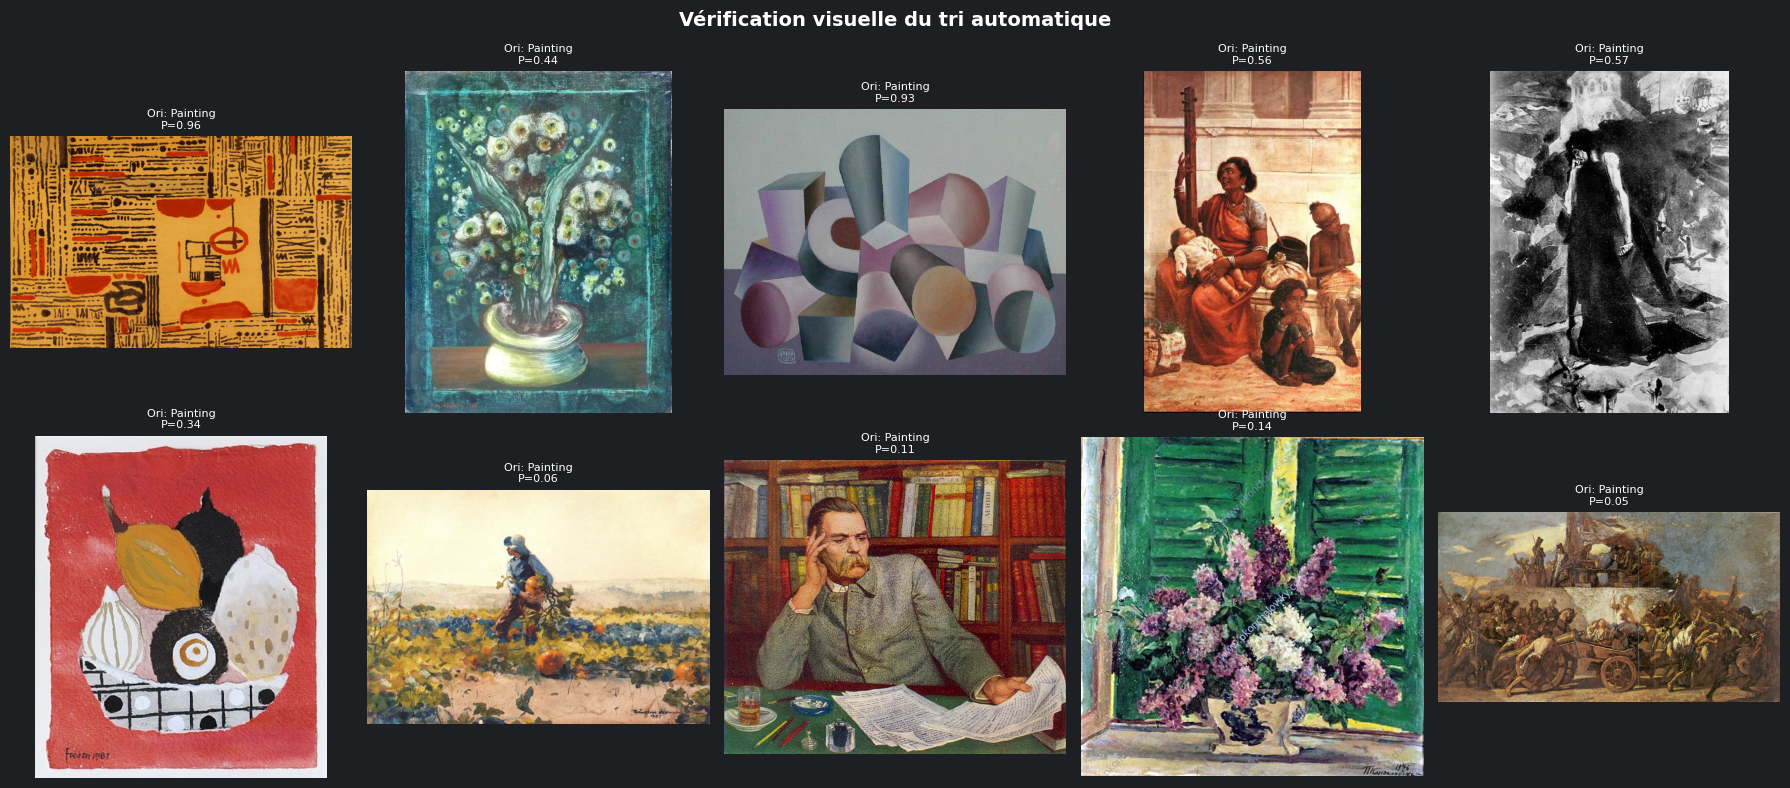

In [19]:
# -----------------------------------------------------------------
# VERIFICATION VISUELLE DU TRI
# Affiche 5 exemples par catégorie triée pour valider manuellement
# que le modèle classe correctement les images.
# -----------------------------------------------------------------
import matplotlib.image as mpimg

# Grille 2 lignes (Photo / Not_Photo) x 5 colonnes
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for row_idx, (cat, folder) in enumerate([
    ('Photo',     DATA_PROC / 'Photo'),
    ('Not_Photo', DATA_PROC / 'Not_Photo')
]):
    # On prend les 5 premières images triées dans ce dossier
    imgs = sorted(list(folder.glob('*.*')))[:5]

    for col_idx in range(5):
        ax = axes[row_idx, col_idx]
        if col_idx < len(imgs):
            try:
                fname = imgs[col_idx].name

                # Cherche dans sort_summary les détails de prédiction de cette image
                # (classe d'origine + probabilité) pour les afficher dans le titre
                detail = next(
                    (d for d in sort_summary['details'] if fname.endswith(d['file'])),
                    None
                )
                ax.imshow(mpimg.imread(str(imgs[col_idx])))
                if detail:
                    ax.set_title(
                        f"Ori: {detail['original_class']}\nP={detail['probability']:.2f}",
                        fontsize=8
                    )
            except Exception:
                pass  # Image illisible -> on affiche juste une case vide
        ax.axis('off')

    # Etiquette de ligne colorée (vert = Photo, rouge = Not_Photo)
    axes[row_idx, 0].set_ylabel(
        f"-> {cat}", fontsize=12, fontweight='bold',
        color='green' if cat == 'Photo' else 'crimson',
        rotation=0, labelpad=70
    )

plt.suptitle('Vérification visuelle du tri automatique', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'sorted_samples.png', dpi=100, bbox_inches='tight')
plt.show()


 Peintures classées comme Photos : 377
   (peintures hyper-réalistes difficiles à distinguer)


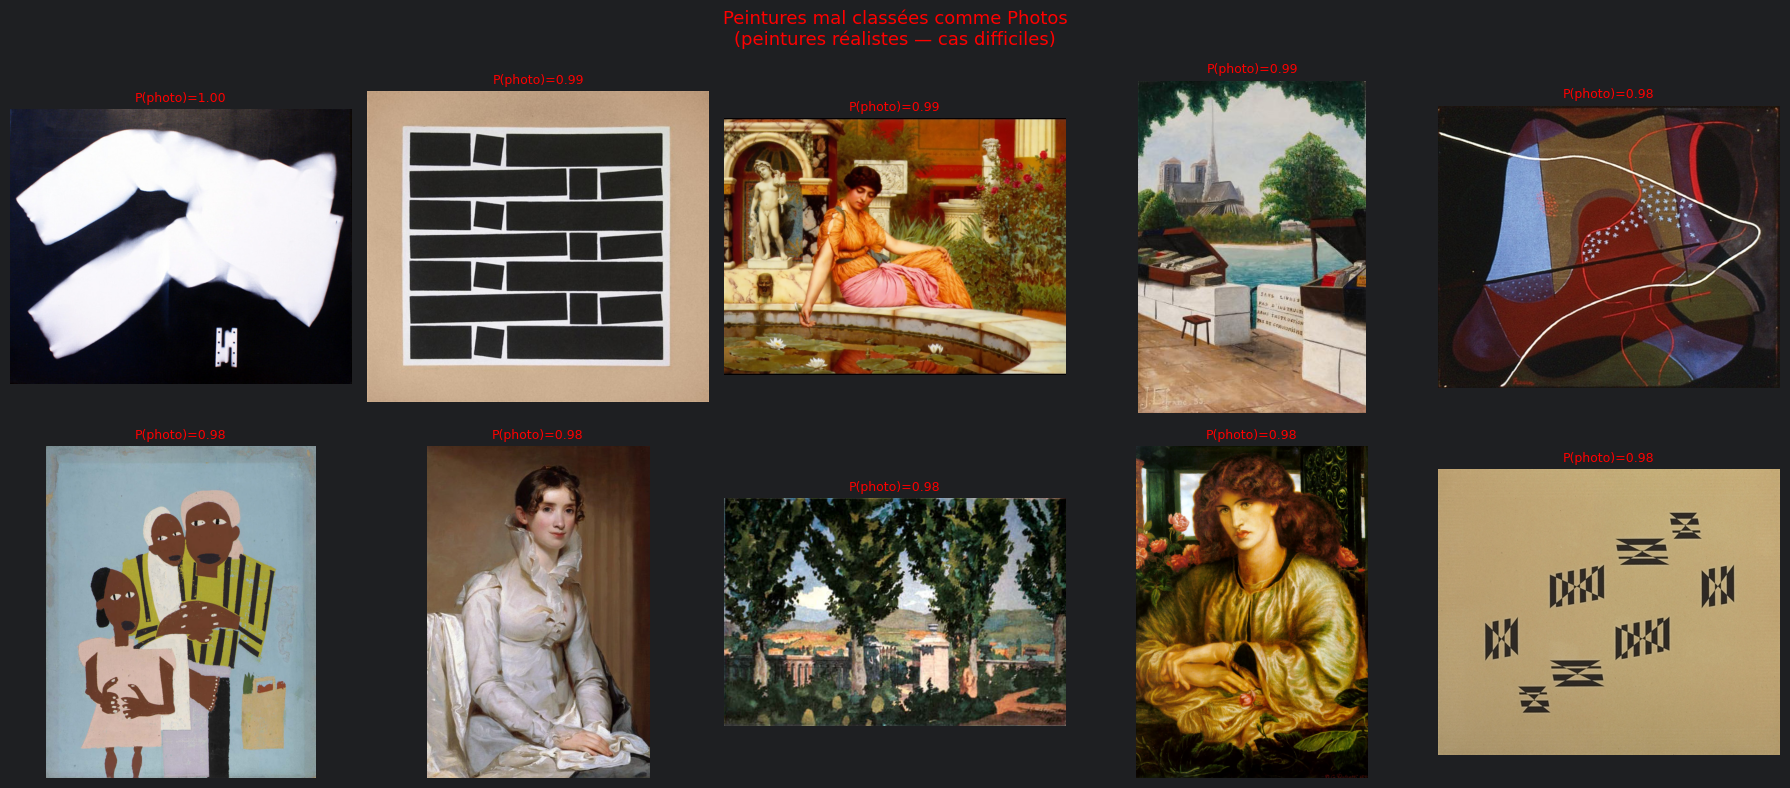

In [20]:
# -----------------------------------------------------------------
# ANALYSE DES ERREURS - Peintures classées comme Photos
# Les peintures réalistes (style hyper-réaliste) sont les cas les
# plus difficiles pour un CNN : leur texture est proche d'une photo.
# Cette analyse aide à comprendre les limites du modèle.
# -----------------------------------------------------------------

# Filtre les cas où une Painting a été classée Photo (faux positifs)
# et les trie par probabilité décroissante -> les plus "confiants" en premier
painting_as_photo = sorted(
    [d for d in sort_summary['details']
     if d['original_class'] == 'Painting' and d['predicted'] == 'Photo'],
    key=lambda x: x['probability'], reverse=True
)

print(f"\n Peintures classées comme Photos : {len(painting_as_photo)}")
print("   (peintures hyper-réalistes difficiles à distinguer)")

if painting_as_photo:
    n_show = min(10, len(painting_as_photo))  # Affiche au maximum 10 images
    fig, axes = plt.subplots(2, 5, figsize=(18, 8))

    for i, d in enumerate(painting_as_photo[:n_show]):
        # Retrouve l'image dans le dossier Photo (où elle a été copiée à tort)
        img_path = DATA_PROC / 'Photo' / f"Painting__{d['file']}"
        if not img_path.exists():
            # Recherche par pattern si le nom exact n'est pas trouvé (doublons renommés)
            candidates = list((DATA_PROC / 'Photo').glob(f"Painting__*{d['file']}"))
            img_path = candidates[0] if candidates else None

        # Placement dans la grille 2x5 : i//5 -> ligne, i%5 -> colonne
        ax = axes[i // 5, i % 5]
        if img_path and img_path.exists():
            try:
                ax.imshow(mpimg.imread(str(img_path)))
                # Affiche la probabilité en rouge -> plus elle est proche de 1,
                # plus le modèle était "certain" (à tort) que c'était une photo
                ax.set_title(f"P(photo)={d['probability']:.2f}", fontsize=9, color='red')
            except Exception:
                pass
        ax.axis('off')

    plt.suptitle(
        'Peintures mal classées comme Photos\n(peintures réalistes - cas difficiles)',
        fontsize=13, color='red'
    )
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'hard_cases.png', dpi=100)
    plt.show()
else:
    print("   Aucune peinture mal classée !")

---
### 8.2 Analyse des faux positifs - Distribution par classe d'origine

Un **faux positif** est une image Non-Photo que le modèle a classée comme Photo.
Analyser leur distribution par classe d'origine révèle **quels types d'images trompent le plus le modèle**.

Formellement, pour une image $x$ :

$$
FP = \{x : y=0 \;\land\; \hat{y}=1\}
$$

#### Pourquoi cette analyse est importante

| Question | Ce que la distribution révèle |
|---|---|
| Quelle classe génère le plus de faux positifs ? | Le cas difficile dominant (ex. peintures réalistes) |
| Le problème est-il concentré ou diffus ? | Si 90% viennent d'une seule classe -> action ciblée possible |
| Comment réduire ces faux positifs ? | Ajouter des exemples difficiles, ajuster le seuil |

#### Interprétation attendue

Pour ce dataset :
- **Painting** : cas le plus difficile - peintures hyper-réalistes avec texture proche d'une photo
- **Schematics / Sketch / Text** : cas plus faciles - structure visuelle très différente

Si la majorité des faux positifs viennent de Painting, la solution est :
1. Ajouter plus d'exemples de Painting dans le train (data augmentation ciblée)
2. Ou collecter des exemples difficiles (hard negative mining)
3. En dernier recours : monter légèrement le seuil `THRESHOLD`

,Classe d'origine,Faux positifs,% des faux positifs
0,Painting,377,76.3%
1,Schematics,116,23.5%
2,Sketch,1,0.2%
3,Text,0,0.0%


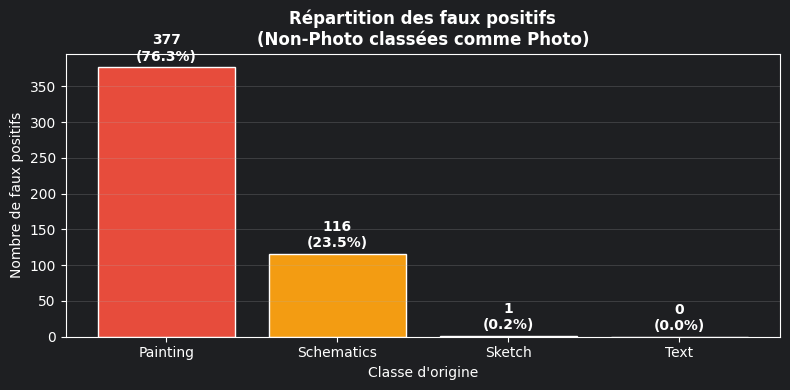

Total faux positifs : 494


In [21]:
# Distribution des faux positifs par classe d'origine
# Faux positif = image Non-Photo prédite comme Photo

df_predictions = pd.DataFrame(sort_summary["details"])

false_positives = df_predictions[
    (df_predictions["original_class"] != "Photo") &
    (df_predictions["predicted"] == "Photo")
]

fp_counts = (
    false_positives["original_class"]
    .value_counts()
    .reindex(["Painting", "Schematics", "Sketch", "Text"], fill_value=0)
)

fp_percent = fp_counts / max(fp_counts.sum(), 1) * 100

display_df = pd.DataFrame({
    "Classe d'origine": fp_counts.index,
    "Faux positifs": fp_counts.values,
    "% des faux positifs": fp_percent.values
})

display(
    display_df.style
        .format({"% des faux positifs": "{:.1f}%"})
        .background_gradient(subset=["Faux positifs"], cmap="Reds")
)

plt.figure(figsize=(8, 4))
bars = plt.bar(
    fp_counts.index,
    fp_counts.values,
    color=["#e74c3c", "#f39c12", "#95a5a6", "#3498db"],
    edgecolor="white"
)

for bar, count, pct in zip(bars, fp_counts.values, fp_percent.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{count}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Répartition des faux positifs\n(Non-Photo classées comme Photo)", fontweight="bold")
plt.xlabel("Classe d'origine")
plt.ylabel("Nombre de faux positifs")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total faux positifs : {fp_counts.sum()}")

---
## 9. Analyse biais/variance & méthodes d'amélioration

### 9.1 Biais vs Variance - rappel théorique

Le compromis biais/variance est fondamental en Machine Learning :

$$
\mathbb{E}\left[(y-\hat{f}(x))^2\right]
= Bias(\hat{f})^2 + Var(\hat{f}) + \sigma^2
$$

| Concept | Définition intuitive | Observable sur les courbes |
|---|---|---|
| **Biais (sous-apprentissage)** | Le modèle est trop simple pour capturer les patterns du dataset | Train acc ET val acc faibles, les deux courbes sont basses |
| **Variance (sur-apprentissage)** | Le modèle mémorise le train au lieu d'apprendre les règles générales | Train acc haute, val acc basse, grand écart entre les courbes |
| **Bon compromis** | Le modèle généralise correctement | Train ~ val, les deux élevées, zone colorée étroite |

### 9.2 Techniques de régularisation appliquées - détail

| Technique | Mécanisme | Effet sur la courbe | Paramétrage choisi |
|---|---|---|---|
| **Dropout(0.5)** | Désactive 50% des neurones aléatoirement à chaque batch | Réduit l'écart train/val | Avant Dense(64), après Dense(128) |
| **Dropout(0.3)** | Désactive 30% des neurones | Régularisation plus légère proche de la sortie | Avant Dense(1) |
| **BatchNormalization** | Normalise les activations (μ=0, σ=1) par batch | Stabilise la convergence | Après chaque Conv et Dense |
| **Augmentation** | Transformations aléatoires des images | Artificiellement augmente la taille effective du dataset | Flip + Rotation + Zoom + Contrast |
| **EarlyStopping** | Arrête si val_loss ne descend plus | Empêche la mémorisation tardive | patience=10, restore_best_weights=True |
| **ReduceLROnPlateau** | Divise le lr par 2 si plateau | Permet une descente plus fine | factor=0.5, patience=5, min_lr=1e-7 |
| **Class Weight** | Pénalise plus les erreurs sur la classe minoritaire | Corrige le biais vers la classe majoritaire | Poids inverses aux fréquences |
| **L2 (1e-4)** | Ajoute $\lambda\lVert w\rVert_2^2$ à la loss | Empêche les poids de trop croître | Sur toutes les couches Conv et Dense |

### 9.3 Axes d'amélioration si les performances sont insuffisantes

#### Si sous-apprentissage (Accuracy < 80%, biais élevé)
1. Augmenter la capacité du modèle (plus de filtres ou de couches)
2. Augmenter le nombre d'epochs (et laisser EarlyStopping décider)
3. Augmenter le learning rate initial (1e-3 à la place de 1e-4)

#### Si sur-apprentissage (grand écart train/val, variance élevée)
1. Renforcer le Dropout (0.5 -> 0.6)
2. Augmenter L2 (1e-4 -> 1e-3)
3. Augmenter les amplitudes d'augmentation
4. Réduire la capacité du modèle (Dense 128 -> 64)

#### Si bonnes performances mais faux positifs sur Painting
1. Ajouter des exemples difficiles de peintures réalistes (hard negative mining)
2. Utiliser la **Focal Loss** : pénalise plus les exemples difficiles
3. Essayer **EfficientNetB0** (Transfer Learning) fine-tuné sur nos données
4. Ajuster le seuil `THRESHOLD` vers le haut pour réduire les faux positifs

#### Amélioration globale recommandée
Comparer ensuite ce CNN from scratch avec un modèle de transfert léger (par exemple EfficientNetB0)
ou lancer une recherche d'hyperparamètres ciblée sur `lr`, `l2_rate`, `dropout` et `dense_units`.
Cette étape est une piste d'amélioration, pas une dépendance du livrable actuel.

---
## 10. Sauvegarde du modèle & métadonnées

### Vue d'ensemble des fichiers produits

```
src/models/
  +-- cnn_scratch.keras        <- modèle final (architecture + poids + config)
  +-- cnn_scratch_best.keras   <- meilleur checkpoint (ModelCheckpoint)

data/processed/
  +-- Photo/                   <- images classées comme photos (préfixées)
  +-- Not_Photo/               <- images classées non-photos (préfixées)
  +-- classification_report.csv <- audit complet des prédictions

notebooks/figures/
  +-- samples.png              <- grille d'exemples par classe
  +-- distribution.png         <- distribution des classes
  +-- augmentation.png         <- exemples d'augmentation
  +-- curves_cnn.png           <- courbes Accuracy / Loss
  +-- eval_cnn_scratch.png     <- matrice de confusion + courbe ROC
  +-- sorted_samples.png       <- vérification visuelle du tri
  +-- hard_cases.png           <- peintures mal classées
```

### Format `.keras` vs autres formats

| Format | Contenu sauvegardé | Compatibilité |
|---|---|---|
| **`.keras`** (choix ici) | Architecture + poids + état optimizer | TF >= 2.12, recommandé |
| `.h5` (HDF5) | Architecture + poids | TF < 2.12, problèmes avec couches custom |
| `SavedModel/` | TF SavedModel complet | Déploiement TF Serving / TFLite |
| `.weights.h5` | Poids seulement | Doit recompiler l'architecture séparément |

### Chargement du modèle sauvegardé

```python
import tensorflow as tf
model = tf.keras.models.load_model('src/models/cnn_scratch.keras')
prob  = float(model.predict(img_batch, verbose=0).flatten()[0])
label = "Photo" if prob >= 0.5 else "Not_Photo"
```

### Rôle du fichier `metadata.json`

Permet de **réutiliser le modèle sans relire le notebook** :
```json
{
  "model": "CNN_Scratch",
  "threshold": 0.35,
  "image_size": [224, 224],
  "classes": {"0": "Not_Photo", "1": "Photo"},
  "results": {"accuracy": 0.9084, "auc": 0.9709, "precision": 0.8703, "recall": 0.9598, "f1": 0.9129, ...}
}
```
Toute application qui charge le modèle lit ce JSON pour connaître le seuil exact à appliquer.

In [22]:
# --- Sauvegarde du modèle au format Keras natif ---
# Le format .keras sauvegarde l'architecture, les poids et la configuration de compilation.
model_cnn.save(str(MODELS_DIR / 'cnn_scratch.keras'))
print(f" Modèle sauvegardé : {MODELS_DIR / 'cnn_scratch.keras'}")

# --- Fichier de métadonnées JSON ---
# Carte d'identité du livrable : paramètres, résultats, seuil et synthèse du tri.
metadata = {
    'project'   : 'Leyenda - Livrable 1',
    'group'     : 'Groupe 2',
    'model'     : 'CNN_Scratch',
    'architecture': {
        'conv_filters': [32, 64, 128, 256],
        'dense_units': [128, 64],
        'dropout': [0.5, 0.3],
        'total_parameters': int(model_cnn.count_params()),
        'optimizer': 'Adam(1e-4)',
        'loss': 'binary_crossentropy',
        'max_epochs': EPOCHS_CNN,
    },
    'threshold' : float(THRESHOLD),
    'threshold_selection': 'Youden J sur validation',
    'image_size': [IMAGE_H, IMAGE_W],
    'classes'   : {'0': 'Not_Photo', '1': 'Photo'},
    'split': {
        'train': int(len(train_paths)),
        'validation': int(len(val_paths)),
        'test': int(len(test_paths)),
    },
    'results'   : {
        'test_accuracy' : float(results_cnn['test_acc']),
        'train_accuracy': float(results_cnn['train_acc']),
        'train_test_gap': float(results_cnn['gap']),
        'auc'           : float(results_cnn['auc']),
        'precision'     : float(results_cnn['precision']),
        'recall'        : float(results_cnn['recall']),
        'f1'            : float(results_cnn['f1']),
    },
    'sort_summary': {
        'processed'  : int(sort_summary['Photo'] + sort_summary['Not_Photo'] + sort_summary['errors']),
        'n_photo'    : int(sort_summary['Photo']),
        'n_not_photo': int(sort_summary['Not_Photo']),
        'errors'     : int(sort_summary['errors'])
    },
    'main_weakness': 'Faux positifs concentrés sur Painting, puis Schematics.'
}

with open(MODELS_DIR / 'metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

# --- Export du rapport de tri au format CSV ---
# Chaque ligne = une image avec : nom, classe d'origine, classe prédite, probabilité.
df_details = pd.DataFrame(sort_summary['details'])
df_details.to_csv(DATA_PROC / 'classification_report.csv', index=False)

print(f" Métadonnées    : {MODELS_DIR / 'metadata.json'}")
print(f" Rapport de tri : {DATA_PROC / 'classification_report.csv'}")
print(f" Figures        : {FIGURES_DIR}")

print("\n  Arborescence data/processed :")
for p in sorted(DATA_PROC.rglob('*'))[:10]:
    indent = '  ' * (len(p.relative_to(DATA_PROC).parts) - 1)
    print(f"  {indent}{p.name}")

 Modèle sauvegardé : /home/aymen/DS/Leyenda/src/models/cnn_scratch.keras
 Métadonnées    : /home/aymen/DS/Leyenda/src/models/metadata.json
 Rapport de tri : /home/aymen/DS/Leyenda/data/processed/classification_report.csv
 Figures        : /home/aymen/DS/Leyenda/notebooks/figures

  Arborescence data/processed :
  .gitkeep
  Not_Photo
    Painting__painting_00008.jpg
    Painting__painting_00025.jpg
    Painting__painting_00036.jpg
    Painting__painting_00041.jpg
    Painting__painting_00044.jpg
    Painting__painting_00046.jpg
    Painting__painting_00049.jpg
    Painting__painting_00064.jpg


---
## 11. Conclusion

### Résumé des résultats

Les valeurs ci-dessous correspondent au dernier run sauvegardé dans les sorties du notebook :

| Indicateur | Valeur |
|---|---:|
| Test Accuracy | 90.84 % |
| AUC-ROC | 0.9709 |
| Precision | 0.8703 |
| Recall | 0.9598 |
| F1-score | 0.9129 |
| Seuil optimal | 0.350 |
| Images Photo triées | 5594 |
| Images Not_Photo triées | 5653 |

### Guide d'interprétation des métriques

| Métrique | Formule | Objectif | Interprétation si insuffisant |
|---|---|---|---|
| **Accuracy** | $\frac{TP+TN}{TP+TN+FP+FN}$ | > 85 % | Modèle peu discriminant ou dataset très déséquilibré |
| **AUC-ROC** | $\int_0^1 TPR(FPR)\,dFPR$ | > 0.90 | Mauvaise séparation Photo / Not_Photo |
| **Precision** | $\frac{TP}{TP+FP}$ | Maximiser si FP coûteux | Trop de peintures classées comme photos |
| **Recall** | $\frac{TP}{TP+FN}$ | > 0.85 | Trop de vraies photos manquées |
| **F1-score** | $\frac{2PR}{P+R}$ | > 0.87 | Déséquilibre Precision/Recall |
| **Ecart bias/var** | $acc_{train}-acc_{test}$ | < 8 % | Sur-apprentissage si > 15 % |

### Critère de déploiement recommandé

Le modèle est considéré prêt à trier automatiquement le dataset si **tous** les critères suivants sont atteints :
- AUC-ROC > 0.90 (bonne discrimination)
- Recall (Photo) > 0.85 (on ne rate pas plus de 15% des vraies photos)
- Ecart biais/variance < 15% (généralisation acceptable)

### Points forts de l'approche

- **CNN from scratch** adapté au domaine Leyenda - pas de biais ImageNet
- **Pipeline complet** et reproductible : seed fixée, split stratifié, augmentation documentée
- **Traçabilité totale** : chaque image -> probabilité + classe d'origine dans le CSV
- **Seuil optimal** Youden J sur val_bin - pas de data leakage sur le test set
- **Robustesse** : EarlyStopping + ModelCheckpoint garantissent la récupération du meilleur état

In [23]:
# Récapitulatif final des métriques et des fichiers produits
print("\n" + "="*65)
print("  RESUME FINAL - Livrable 1 / Groupe 2")
print("="*65)
print(f"""
  MODELE          : CNN from scratch
  Test Accuracy   : {results_cnn['test_acc']:.2%}
  AUC-ROC         : {results_cnn['auc']:.4f}
  Precision       : {results_cnn['precision']:.4f}
  Recall          : {results_cnn['recall']:.4f}
  Ecart biais/var : {results_cnn['gap']*100:.1f}%

  Images triées :
      Photo     : {sort_summary['Photo']}
      Not_Photo : {sort_summary['Not_Photo']}

  Dossiers de sortie :
    {DATA_PROC / 'Photo'}
    {DATA_PROC / 'Not_Photo'}
""")
print("="*65)
print("""
   Points forts de l'approche :
    - CNN entraîné sur nos données -> adapté au domaine
    - 4 blocs convolutifs + GlobalAveragePooling -> robuste
    - Augmentation intégrée -> meilleure généralisation
    - Class weight -> corrige le déséquilibre Photo/Non-Photo
    - EarlyStopping + ReduceLROnPlateau -> évite le surapprentissage
    - Tri automatique avec traçabilité (CSV + probabilités)

   Cas difficiles identifiés :
    - Peintures réalistes -> faux positifs possibles
    - Ajuster THRESHOLD si précision > rappel requis
""")


  RESUME FINAL - Livrable 1 / Groupe 2

  MODELE          : CNN from scratch
  Test Accuracy   : 90.84%
  AUC-ROC         : 0.9709
  Precision       : 0.8703
  Recall          : 0.9598
  Ecart biais/var : 1.8%

  Images triées :
      Photo     : 5594
      Not_Photo : 5653

  Dossiers de sortie :
    /home/aymen/DS/Leyenda/data/processed/Photo
    /home/aymen/DS/Leyenda/data/processed/Not_Photo


   Points forts de l'approche :
    - CNN entraîné sur nos données -> adapté au domaine
    - 4 blocs convolutifs + GlobalAveragePooling -> robuste
    - Augmentation intégrée -> meilleure généralisation
    - Class weight -> corrige le déséquilibre Photo/Non-Photo
    - EarlyStopping + ReduceLROnPlateau -> évite le surapprentissage
    - Tri automatique avec traçabilité (CSV + probabilités)

   Cas difficiles identifiés :
    - Peintures réalistes -> faux positifs possibles
    - Ajuster THRESHOLD si précision > rappel requis



---
## 12. Test sur une image personnalisée


### Interprétation du résultat

| P(Photo) | Couleur | Décision | Signification |
|---|---|---|---|
| >= `THRESHOLD` | Vert | **Photo** | Image reconnue comme photographie réelle |
| < `THRESHOLD` | Rouge | **Not_Photo** | Image classée parmi peinture / schéma / croquis / texte |

### Confiance de la prédiction

La confiance affichée correspond à la probabilité de la classe finalement choisie :

$$
confidence =
\begin{cases}
p & \text{si } p \ge \tau \\
1-p & \text{si } p < \tau
\end{cases}
$$

- Confiance = 95% et décision = Photo -> le modèle est très sûr
- Confiance = 55% -> cas limite, le modèle hésite -> vérification manuelle recommandée

### Ajuster le seuil manuellement

| Scénario | Seuil recommandé | Effet |
|---|---|---|
| Priorité Recall (ne pas rater de photos) | Baisser à 0.30-0.40 | Plus de photos détectées, plus de faux positifs |
| Priorité Precision (peu de faux positifs) | Monter à 0.60-0.70 | Moins de fausses alarmes, quelques photos manquées |
| Equilibre optimal (par défaut) | `THRESHOLD` issu de Youden J | Maximize TPR - FPR simultanément |

> **Rappel** : `THRESHOLD` a été calculé automatiquement via l'index de Youden J
> sur le jeu de validation - c'est la valeur optimale pour ce modèle et ce dataset.

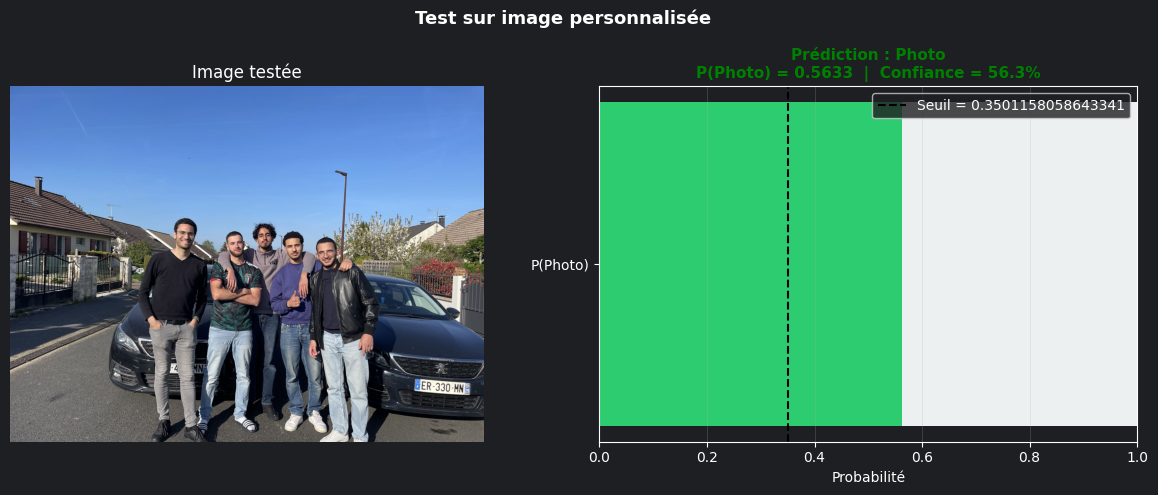

Fichier   : image.jpg
Classe    : Photo
P(Photo)  : 0.5633
Confiance : 56.3%


In [24]:
import matplotlib.image as mpimg

# === MODIFIEZ CE CHEMIN ===
IMAGE_TEST = Path("../image.jpg")
# ===========================

image_path = Path(IMAGE_TEST)

if not image_path.exists():
    print(f"Image introuvable : {image_path}")
else:
    # Chargement
    raw = tf.io.read_file(str(image_path))
    img = tf.io.decode_image(raw, channels=3, expand_animations=False)

    # Redimensionnement au format attendu par le modèle (224x224)
    img_resized = tf.image.resize(img, (IMAGE_H, IMAGE_W))

    # Ajout de la dimension batch : (H,W,C) -> (1,H,W,C)
    img_batch = tf.expand_dims(img_resized, axis=0)

    # Prédiction
    prob = float(model_cnn.predict(img_batch, verbose=0).flatten()[0])
    label = "Photo" if prob >= THRESHOLD else "Not_Photo"
    confidence = prob if prob >= THRESHOLD else 1.0 - prob
    color = "green" if label == "Photo" else "crimson"

    # Affichage
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(mpimg.imread(str(image_path)))
    axes[0].set_title("Image testée", fontsize=12)
    axes[0].axis("off")

    bar_color = "#2ecc71" if prob >= THRESHOLD else "#e74c3c"
    axes[1].barh(["P(Photo)"], [1.0], color="#ecf0f1", height=0.4)
    axes[1].barh(["P(Photo)"], [prob], color=bar_color, height=0.4)
    axes[1].axvline(x=THRESHOLD, color="black", linestyle="--",
                    linewidth=1.5, label=f"Seuil = {THRESHOLD}")
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel("Probabilité")
    axes[1].set_title(
        f"Prédiction : {label}\n"
        f"P(Photo) = {prob:.4f}  |  Confiance = {confidence:.1%}",
        fontsize=11, color=color, fontweight="bold"
    )
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis="x")

    plt.suptitle("Test sur image personnalisée", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(f"Fichier   : {image_path.name}")
    print(f"Classe    : {label}")
    print(f"P(Photo)  : {prob:.4f}")
    print(f"Confiance : {confidence:.1%}")


Fichier      : image.jpg
Classe prédite : Photo
Confiance      : 95.78%


,Classe,Probabilité
1,Photo,0.9578
0,Painting,0.0323
2,Schematics,0.0098
4,Text,0.0001
3,Sketch,0.0000


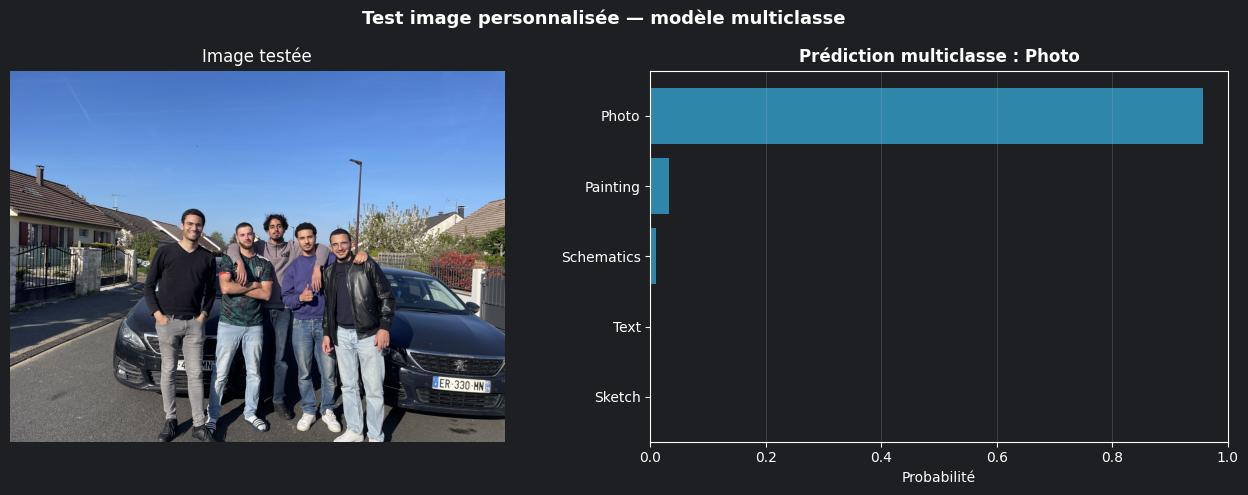

In [25]:
# Test sur une image personnalisée avec le modèle MULTICLASSE

import matplotlib.image as mpimg

IMAGE_TEST = Path("../image.jpg")  # même image que le test binaire
image_path = Path(IMAGE_TEST)

if not image_path.exists():
    print(f"Image introuvable : {image_path}")
else:
    raw = tf.io.read_file(str(image_path))
    img = tf.io.decode_image(raw, channels=3, expand_animations=False)
    img_resized = tf.image.resize(img, (IMAGE_H, IMAGE_W))
    img_batch = tf.expand_dims(img_resized, axis=0)

    probs = model_multiclass.predict(img_batch, verbose=0).flatten()
    pred_idx = int(np.argmax(probs))
    pred_class = class_names[pred_idx]
    confidence = float(probs[pred_idx])

    results_df = pd.DataFrame({
        "Classe": class_names,
        "Probabilité": probs
    }).sort_values("Probabilité", ascending=False)

    print(f"Fichier      : {image_path.name}")
    print(f"Classe prédite : {pred_class}")
    print(f"Confiance      : {confidence:.2%}")
    display(results_df.style.format({"Probabilité": "{:.4f}"}))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].imshow(mpimg.imread(str(image_path)))
    axes[0].set_title("Image testée", fontsize=12)
    axes[0].axis("off")

    axes[1].barh(results_df["Classe"], results_df["Probabilité"], color="#2E86AB")
    axes[1].invert_yaxis()
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel("Probabilité")
    axes[1].set_title(f"Prédiction multiclasse : {pred_class}", fontweight="bold")
    axes[1].grid(axis="x", alpha=0.3)

    plt.suptitle("Test image personnalisée - modèle multiclasse", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()